In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [2]:
label_df = pd.read_csv("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/Baeklab.070.GP3.depth5_None.twm6astrict.tsv", sep="\t")
label_df = label_df[["id", "depth", "label", "m6A_level", "5mer", "drach"]]
label_df.rename(columns = {"id": "label_id","m6A_level": "dom_label"}, inplace = True)
label_df_filtered = label_df[((label_df["dom_label"] > 0.0) & (label_df["label"] == 1)) | (label_df["label"] == 0)]
print(label_df_filtered["label"].value_counts())



label
0    18399879
1      100118
Name: count, dtype: int64


In [13]:
pca_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pca/pileup.npz"
with np.load(pca_df, allow_pickle=True) as data:
    pca_df = pd.DataFrame({key: data[key] for key in data.keys()})
pca_df = pca_df[pca_df["count_dom"] >= 20]
pca_df = pca_df.merge(label_df_filtered, on="label_id", how="inner")
print(pca_df)

                label_id      pm6a  count_pm6a  pca  count_pca  logsum_pca  \
0         NM_000016:1000  0.000000           0  1.0        255 -956.270691   
1         NM_000016:1008  0.000000           0  1.0        256 -889.857605   
2         NM_000016:1009  0.000000           0  1.0        253 -797.323303   
3         NM_000016:1010  0.000000           0  1.0        251 -829.828186   
4         NM_000016:1014  0.000000           0  1.0        251 -846.109802   
...                  ...       ...         ...  ...        ...         ...   
10794116  NR_182669:3964  0.000000           0  1.0         50 -159.479523   
10794117  NR_182669:3965  0.000000           0  1.0         51 -162.836075   
10794118  NR_182669:3966  0.000000           0  1.0         47 -138.327194   
10794119  NR_182669:3968  0.984304           1  1.0         45 -127.156105   
10794120  NR_182669:3969  0.000000           0  1.0         42 -121.713493   

               dom  count_dom  count  logsum_pm6a  depth  label

In [4]:
cell_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup/pileup.pkl"
cell_df = pd.read_pickle(cell_df)
cell_df = cell_df[cell_df["count_pm6a"] >= 20]
cell_label_df = cell_df.merge(label_df_filtered, on="label_id", how="inner")
cell_label_df["threshold"] = 1-((0.9 ** (1-cell_label_df["dom"])) * (0.02 ** (cell_label_df["dom"])))
cell_label_df["discarded_ratio"] = (cell_label_df["count_dom"] - cell_label_df["count_pm6a"]) / cell_label_df["count_dom"]


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


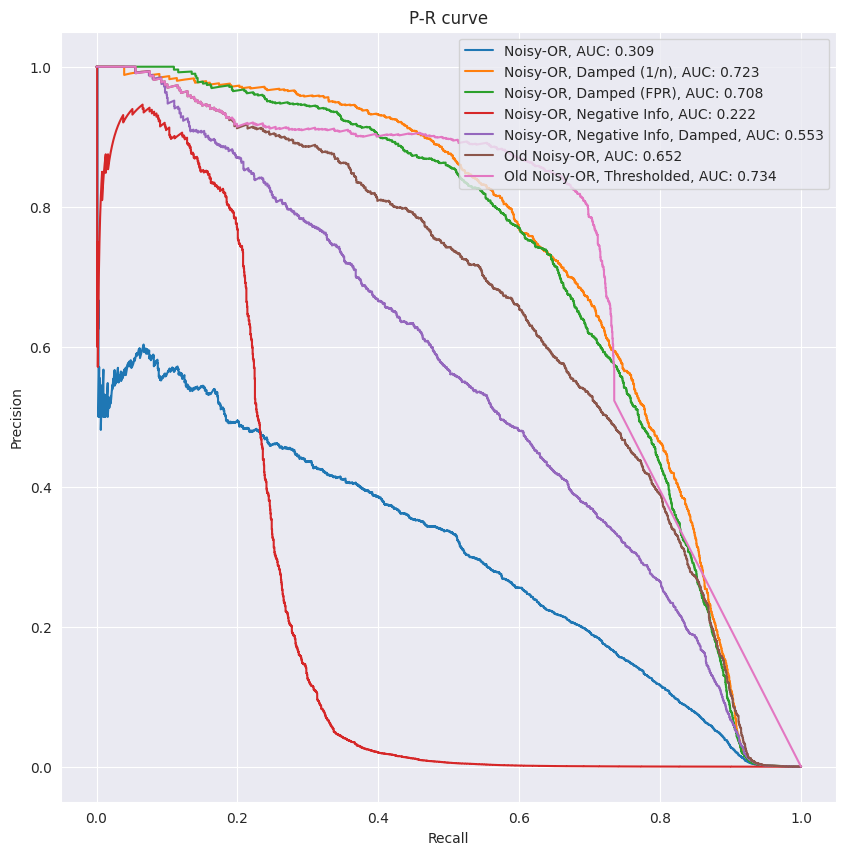

In [14]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"])) 
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")

selected_df = cell_label_df[(~cell_label_df["drach"]) & (cell_label_df["count_pm6a"] >= 100) & (cell_label_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Old Noisy-OR, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Old Noisy-OR, Thresholded, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


In [171]:

selected_df = cell_label_df[(~cell_label_df["drach"]) & (cell_label_df["count_pm6a"] >= 100) & (cell_label_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
print(selected_df)

                label_id      pm6a  count_pm6a       dom  count_dom  \
1         NM_000016:1008  0.001473       256.0  0.000000        256   
2         NM_000016:1009  0.001691       253.0  0.003891        257   
3         NM_000016:1010  0.003384       251.0  0.011583        259   
4         NM_000016:1014  0.003286       251.0  0.000000        252   
5         NM_000016:1020  0.002508       257.0  0.000000        259   
...                  ...       ...         ...       ...        ...   
10461780   NR_182661:933  0.005677       103.0  0.018519        108   
10461783   NR_182661:948  0.007789       104.0  0.027523        109   
10461784   NR_182661:951  0.004702       106.0  0.009259        108   
10461787   NR_182661:975  0.001934       104.0  0.009524        105   
10461790   NR_182661:993  0.003463       100.0  0.019417        103   

          mean_pred  depth  label  dom_label   5mer  drach  threshold  \
1          0.001445    268      0        0.0  GGAAA  False   0.100000   
2

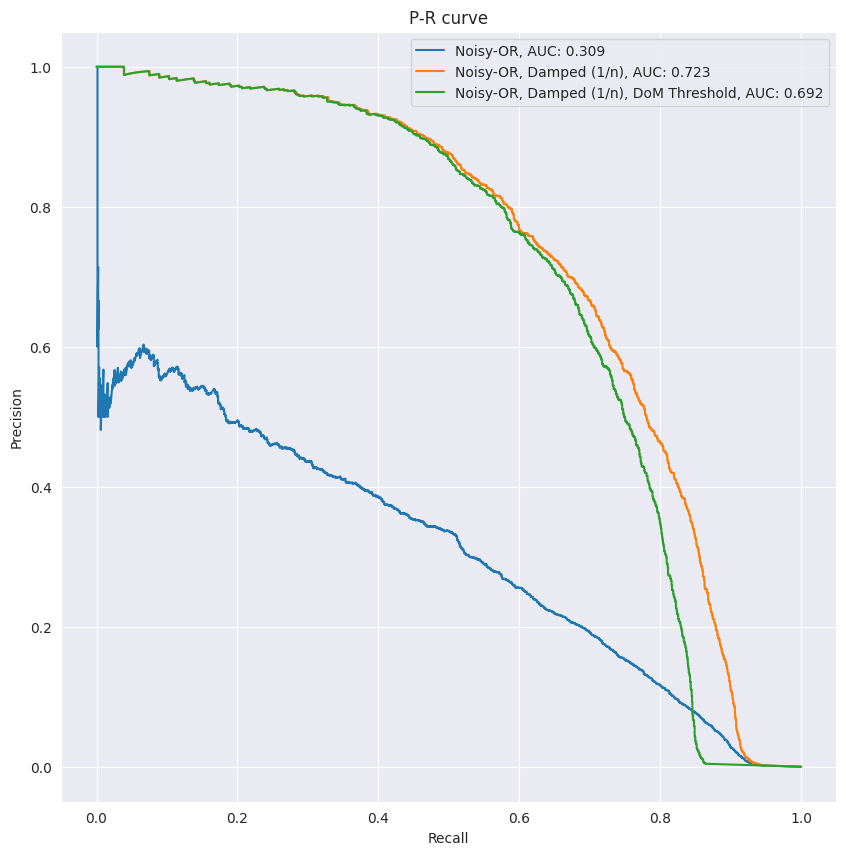

In [55]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr
selected_df["threshold"] = 1- 0.02 ** (cell_label_df["dom"])
selected_df["pm6a_damp_abs_dom"] = selected_df["pm6a_damp_abs"] * (selected_df["pm6a_damp_abs"] > selected_df["threshold"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs_dom"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), DoM Threshold, AUC: {auc_score:.3f}")



ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


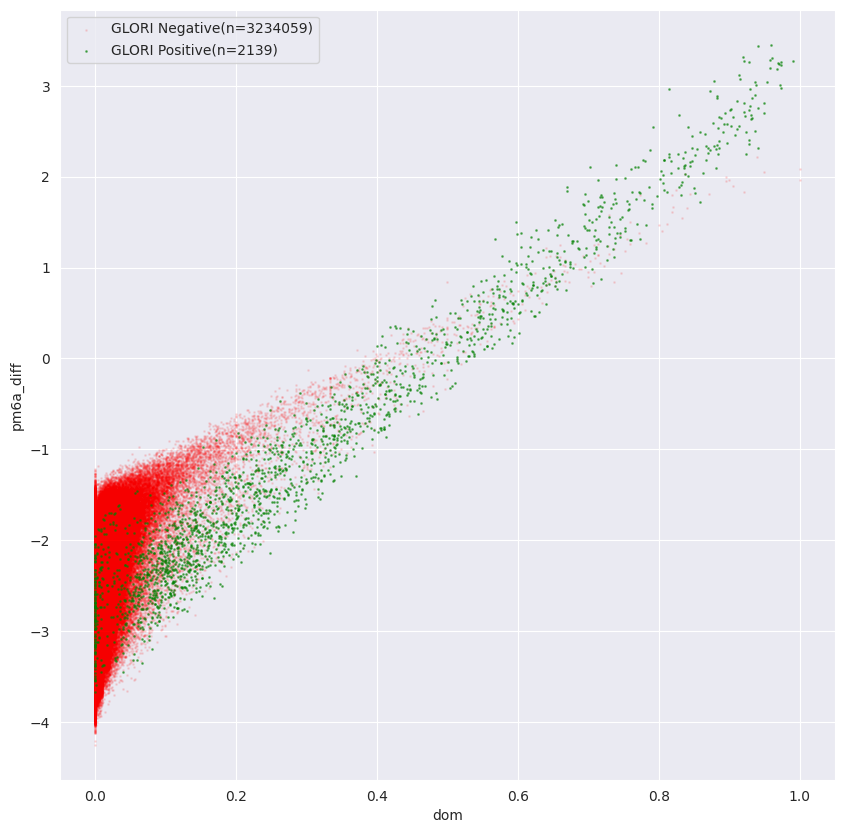

In [15]:
fpr = 0.0027
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

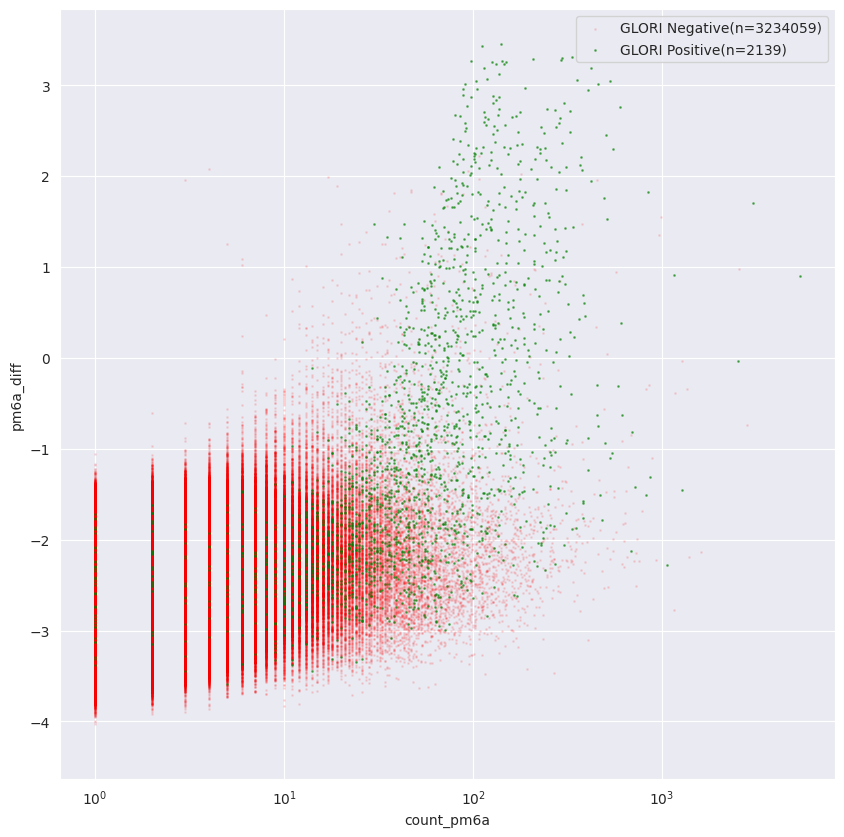

In [16]:
fpr = 0.0027
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"], neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"], pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("count_pm6a")
ax.set_ylabel("pm6a_diff")
ax.set_xscale("log")
plt.show()
plt.close() 

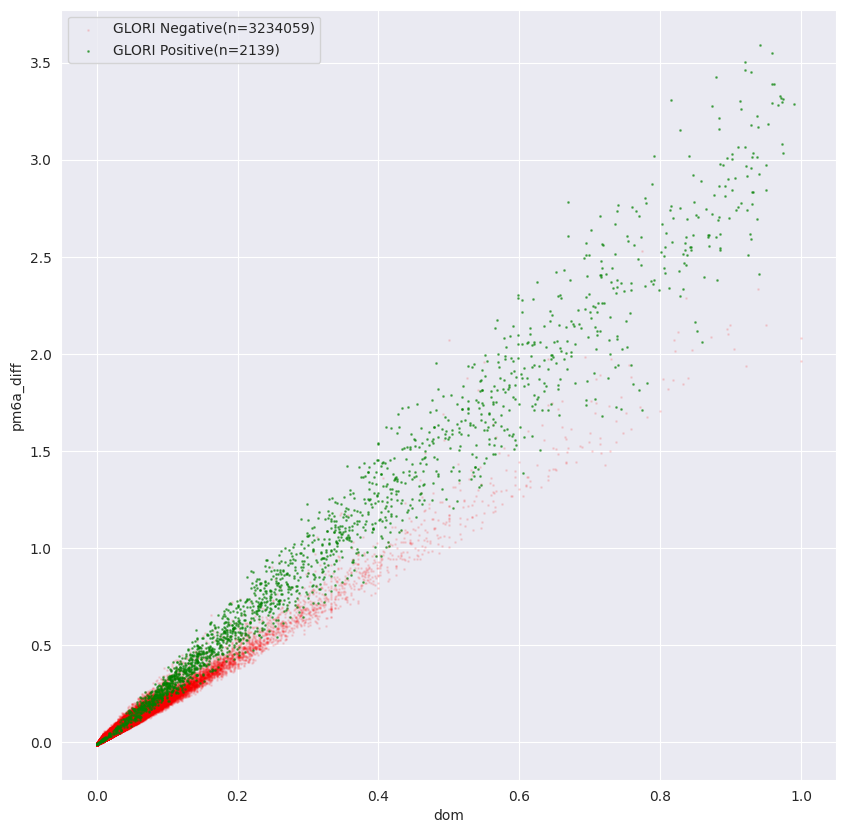

In [17]:
fpr = 0.0027
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

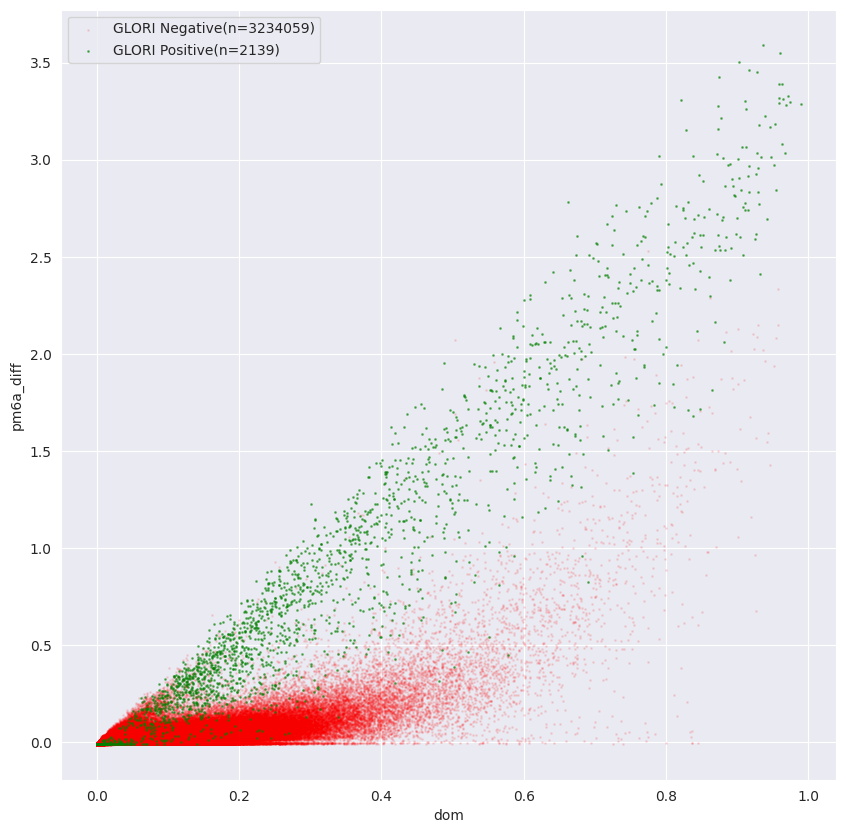

In [18]:
fpr = 0.0027
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["dom"], pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

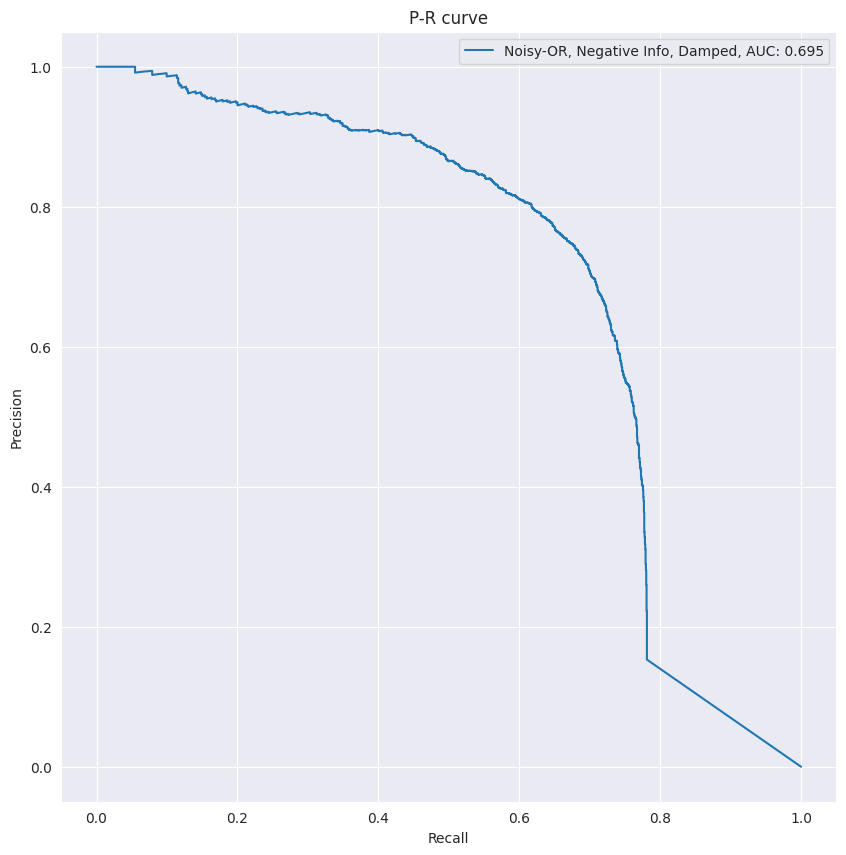

In [19]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)] 
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr
selected_df["threshold"] = -np.log10(fpr) * selected_df["count_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"])
selected_df["pm6a_diff_damp"] = selected_df["pm6a_diff_damp"] * ((selected_df["pm6a_diff_damp"] > selected_df["threshold"]) & (selected_df["dom"] > 0.05))


fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


(array([2.12885275, 0.36346266, 0.48028995, 0.63605966, 0.58413642,
        0.98654152, 0.86971423, 1.05144556, 0.97356071, 0.97356071,
        0.84375261, 0.72692533, 0.76586776, 0.70096371, 0.44134752,
        0.72692533, 0.62307885, 0.48028995, 0.36346266, 0.55817481,
        0.62307885, 0.33750105, 0.48028995, 0.38942428, 0.42836671,
        0.22067376, 0.36346266, 0.35048185, 0.25961619, 0.32452024,
        0.35048185, 0.29855862, 0.31153943, 0.24663538, 0.28557781,
        0.272597  , 0.1427889 , 0.22067376, 0.29855862, 0.18173133,
        0.23365457, 0.09086567, 0.23365457, 0.22067376, 0.20769295,
        0.25961619, 0.11682728, 0.23365457, 0.22067376, 0.20769295,
        0.15576971, 0.18173133, 0.15576971, 0.1427889 , 0.15576971,
        0.19471214, 0.10384648, 0.19471214, 0.09086567, 0.15576971,
        0.09086567, 0.10384648, 0.05192324, 0.10384648, 0.10384648,
        0.10384648, 0.1427889 , 0.10384648, 0.07788486, 0.09086567,
        0.10384648, 0.1427889 , 0.15576971, 0.02

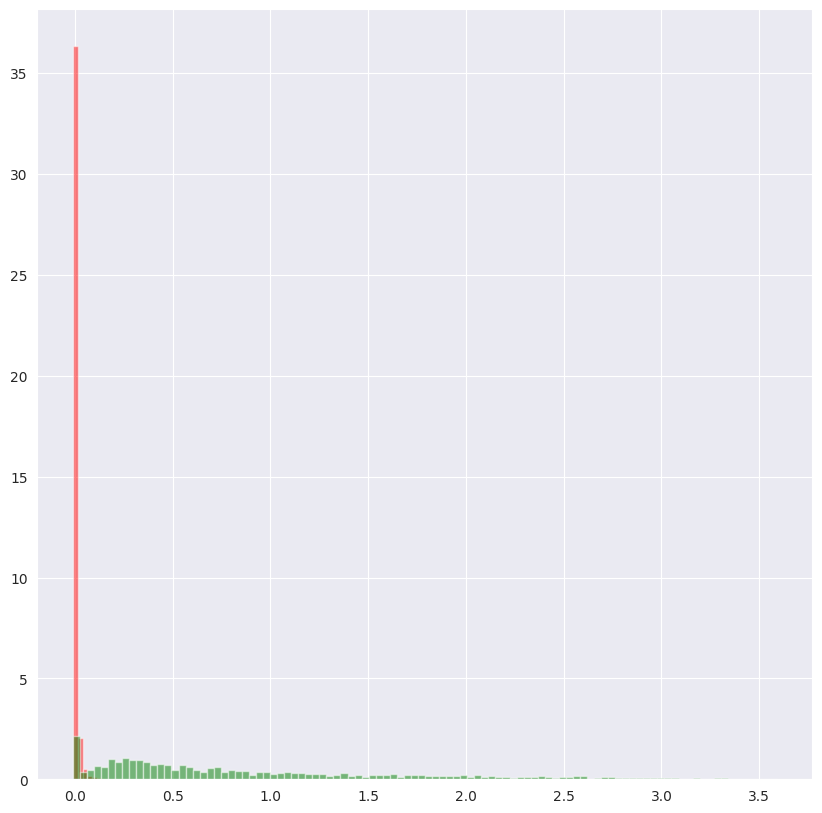

In [20]:
fpr = 0.0027
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.hist(neg_df["pm6a_diff"], bins=100, alpha=0.5, color="red", label=f"GLORI Negative(n={len(neg_df)})", density=True)
ax.hist(pos_df["pm6a_diff"], bins=100, alpha=0.5, color="green", label=f"GLORI Positive(n={len(pos_df)})", density=True)

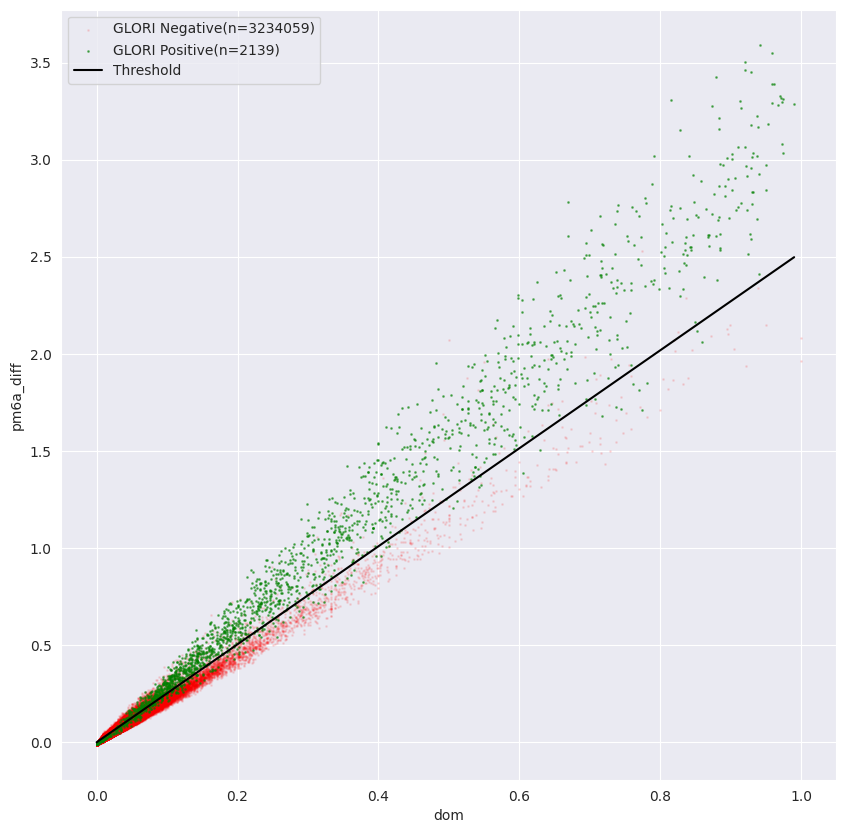

In [24]:
fpr = 0.003
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

x = np.arange(0,1,0.01)
y = -np.log10(fpr) * x

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.plot(x, y, color="black", label="Threshold")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

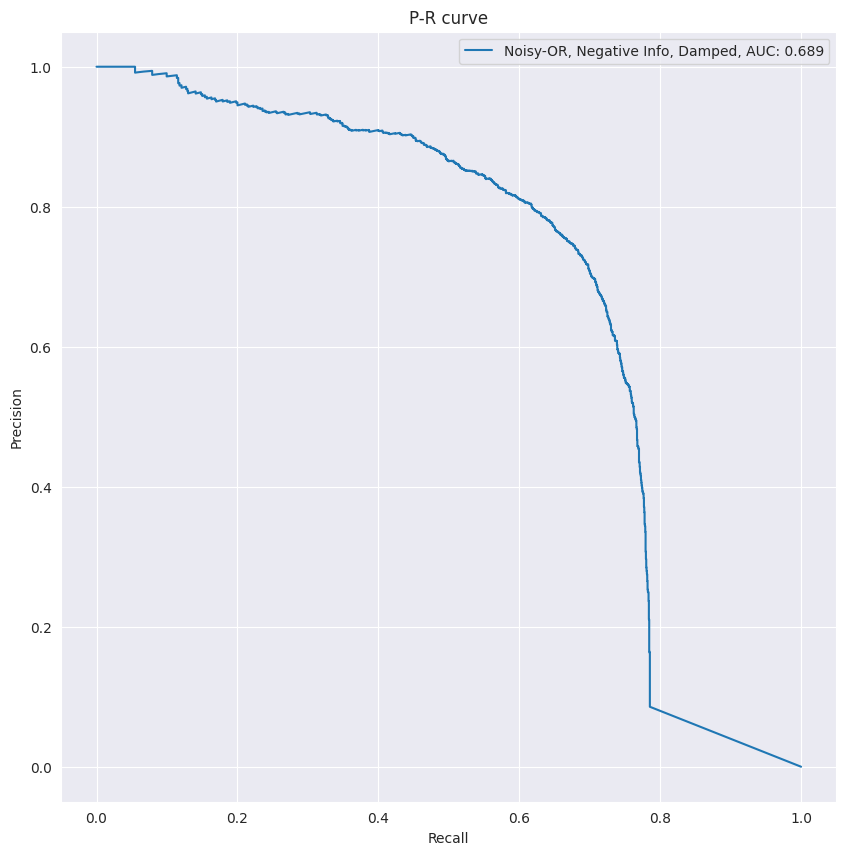

In [23]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr
selected_df["threshold"] = -np.log10(fpr) * selected_df["count_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"])
selected_df["pm6a_diff_damp"] = selected_df["pm6a_diff_damp"] * ((selected_df["pm6a_diff_damp"] > selected_df["threshold"]) & (selected_df["dom"] > 0.001))


fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


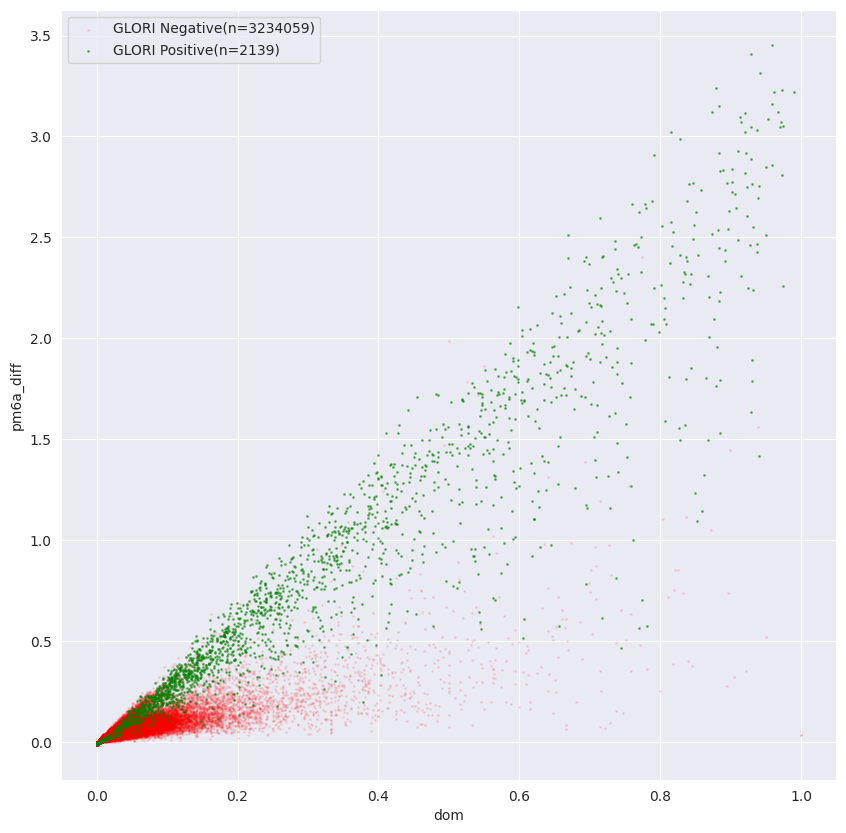

In [25]:
fpr = 0.003
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count"]) + selected_df["logsum_pca"]/(selected_df["count"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0] 

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})") 

ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

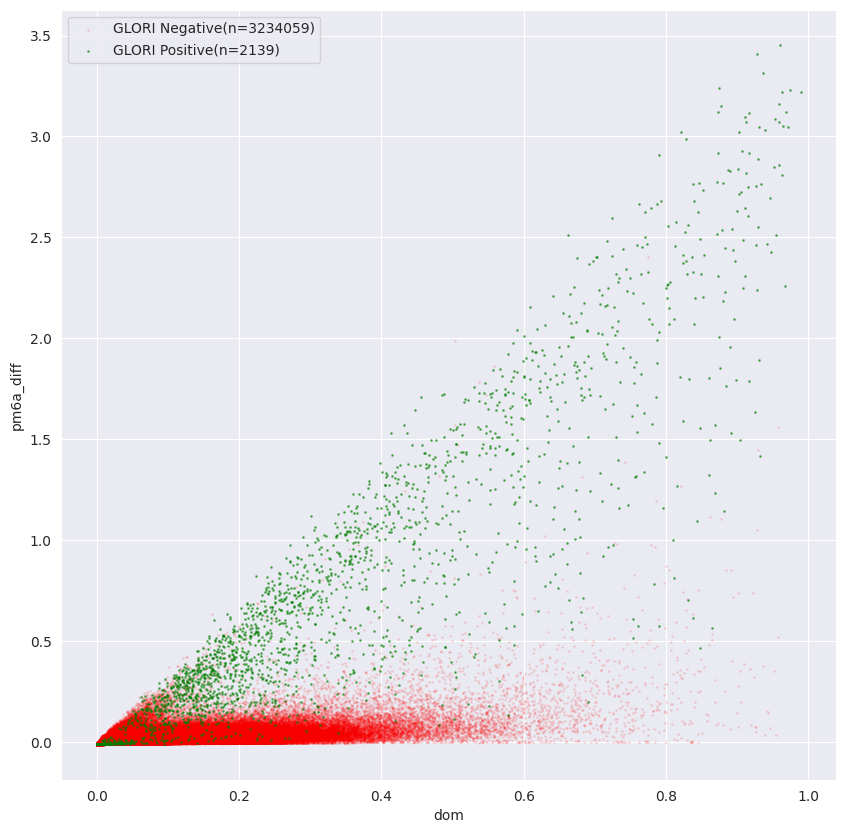

In [26]:
fpr = 0.003
selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count"]) + selected_df["logsum_pca"]/(selected_df["count"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["dom"], pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")

ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

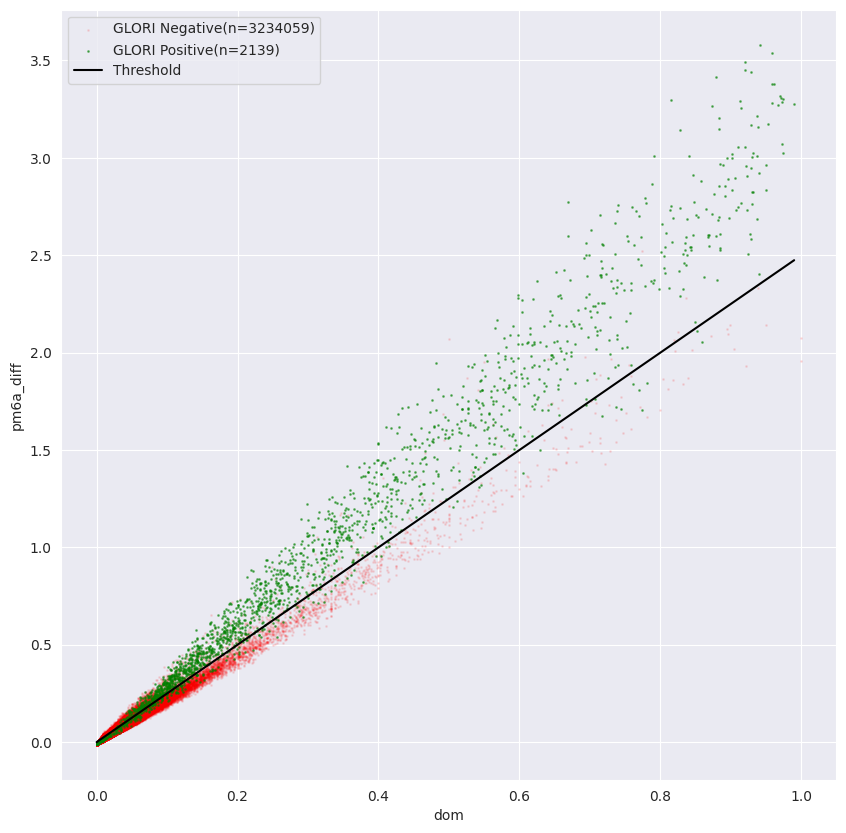

In [35]:
fpr = 0.0027

tnr = 0.8490

fpr_adj = fpr / (fpr + tnr)
tnr_adj = 1 - fpr_adj

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) * tnr_adj + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) * fpr_adj

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]


x = np.arange(0,1,0.01)
y = -np.log10(fpr_adj) * x

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.plot(x, y, color="black", label="Threshold")

ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close()

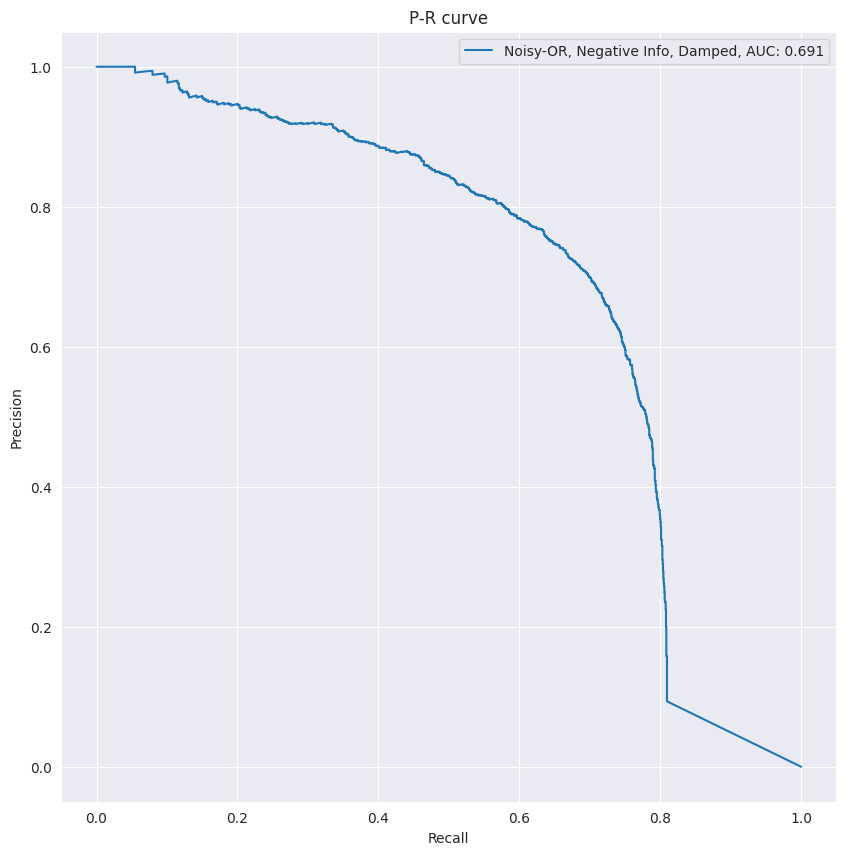

In [41]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027
tnr = 0.8490
fpr_adj = fpr / (fpr + tnr)
tnr_adj = 1 - fpr_adj

selected_df = pca_df[(~pca_df["drach"]) & (pca_df["count_dom"] >= 100) & (pca_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)] 
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) * tnr_adj + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) * fpr_adj
selected_df["threshold"] = -np.log10(fpr_adj) * selected_df["count_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"])
selected_df["pm6a_diff_damp"] = selected_df["pm6a_diff_damp"] * (selected_df["pm6a_diff_damp"] > selected_df["threshold"]) 


fig, ax = plt.subplots(1, 1, figsize=(10, 10))


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


In [45]:
pca_50_50_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_pca_50_50/pileup.npz"
with np.load(pca_50_50_df, allow_pickle=True) as data:
    pca_50_50_df = pd.DataFrame({key: data[key] for key in data.keys()})
pca_50_50_df = pca_50_50_df[pca_50_50_df["count_dom"] >= 20]
pca_50_50_df = pca_50_50_df.merge(label_df_filtered, on="label_id", how="inner")
print(pca_50_50_df)

                label_id      pm6a  count_pm6a  pca  count_pca  logsum_pca  \
0         NM_000016:1000  0.000000           0  1.0        258 -958.656189   
1         NM_000016:1008  0.578929           1  1.0        256 -889.857605   
2         NM_000016:1009  0.869907           1  1.0        259 -801.472900   
3         NM_000016:1010  0.984075           4  1.0        259 -835.746582   
4         NM_000016:1014  0.503992           1  1.0        257 -849.125244   
...                  ...       ...         ...  ...        ...         ...   
10794116  NR_182669:3964  0.000000           0  1.0         54 -161.872665   
10794117  NR_182669:3965  0.567227           1  1.0         52 -163.146851   
10794118  NR_182669:3966  0.626337           1  1.0         49 -139.853226   
10794119  NR_182669:3968  0.997981           2  1.0         46 -127.909309   
10794120  NR_182669:3969  0.853994           2  1.0         43 -122.589272   

               dom  count_dom  count  logsum_pm6a  depth  label

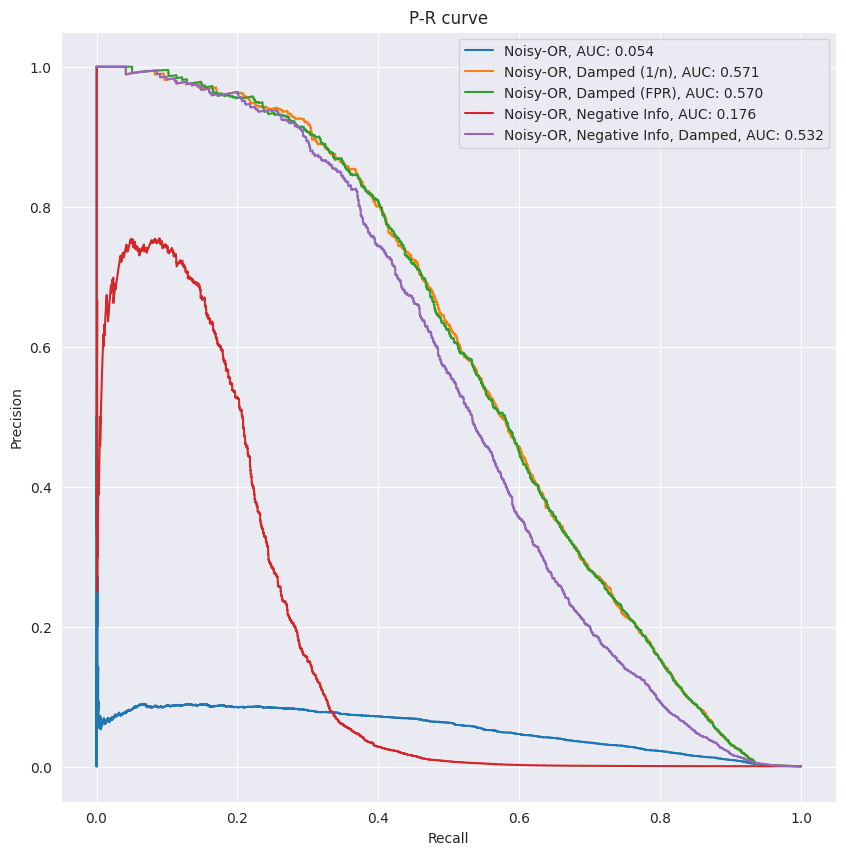

In [46]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.041

selected_df = pca_50_50_df[(~pca_50_50_df["drach"]) & (pca_50_50_df["count_dom"] >= 100) & (pca_50_50_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


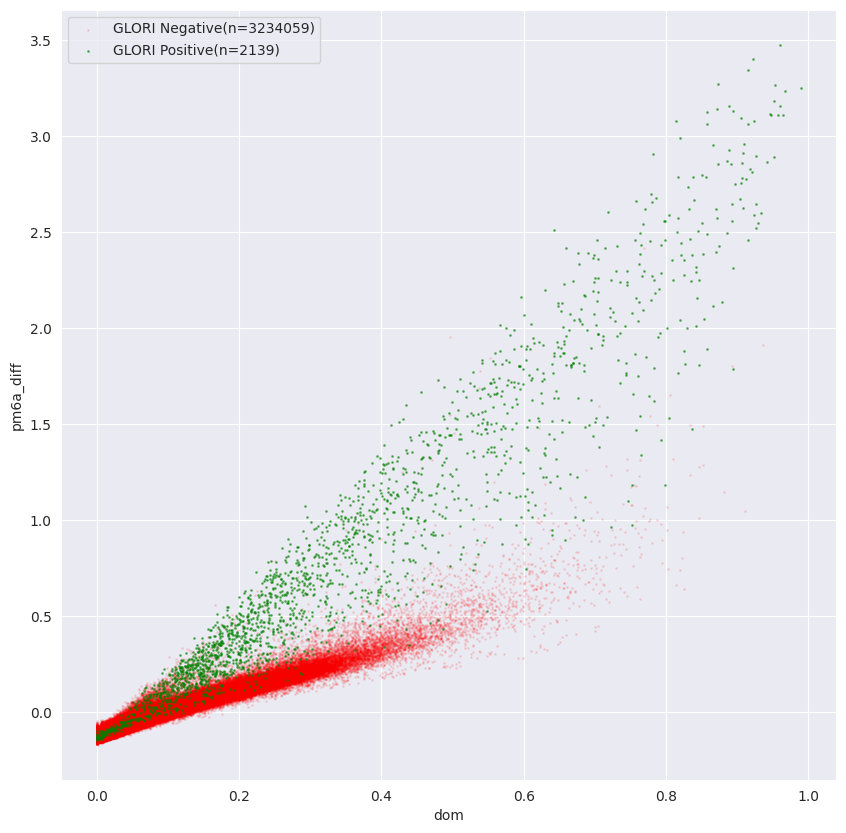

In [47]:
fpr = 0.041
selected_df = pca_50_50_df[(~pca_50_50_df["drach"]) & (pca_50_50_df["count_dom"] >= 100) & (pca_50_50_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

In [49]:
pca_20_90_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_pca_20_90/pileup.npz"
with np.load(pca_20_90_df, allow_pickle=True) as data:
    pca_20_90_df = pd.DataFrame({key: data[key] for key in data.keys()})
pca_20_90_df = pca_20_90_df[pca_20_90_df["count_dom"] >= 20]
pca_20_90_df = pca_20_90_df.merge(label_df_filtered, on="label_id", how="inner")
print(pca_20_90_df)

                label_id      pm6a  count_pm6a  pca  count_pca  logsum_pca  \
0         NM_000016:1000  0.000000           0  1.0        258 -958.656189   
1         NM_000016:1008  0.000000           0  1.0        256 -889.857605   
2         NM_000016:1009  0.000000           0  1.0        256 -799.824646   
3         NM_000016:1010  0.000000           0  1.0        256 -834.004578   
4         NM_000016:1014  0.000000           0  1.0        252 -846.813416   
...                  ...       ...         ...  ...        ...         ...   
10794116  NR_182669:3964  0.000000           0  1.0         51 -160.320465   
10794117  NR_182669:3965  0.000000           0  1.0         51 -162.836075   
10794118  NR_182669:3966  0.000000           0  1.0         49 -139.853226   
10794119  NR_182669:3968  0.984304           1  1.0         46 -127.909309   
10794120  NR_182669:3969  0.000000           0  1.0         43 -122.589272   

               dom  count_dom  count  logsum_pm6a  depth  label

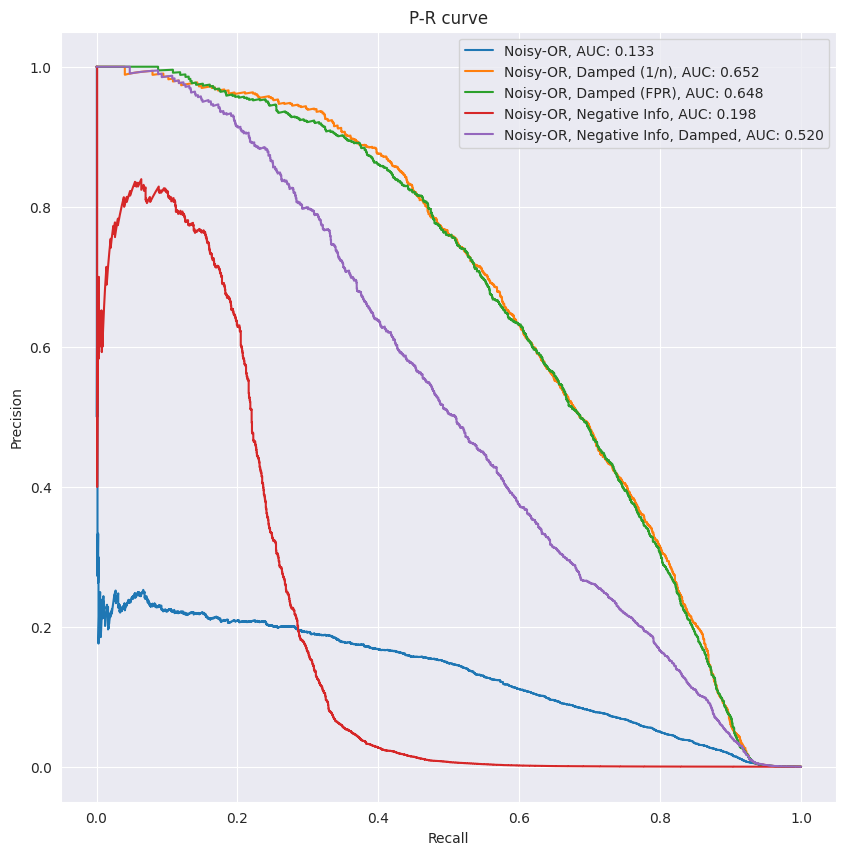

In [50]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0096

selected_df = pca_20_90_df[(~pca_20_90_df["drach"]) & (pca_20_90_df["count_dom"] >= 100) & (pca_20_90_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


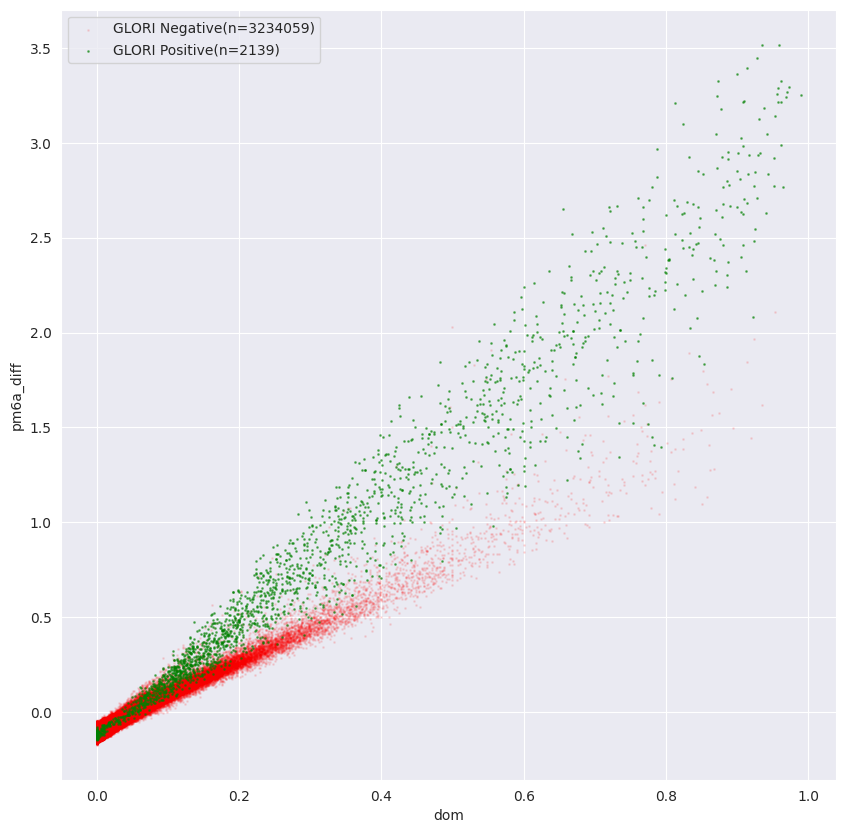

In [51]:
fpr = 0.041
selected_df = pca_20_90_df[(~pca_20_90_df["drach"]) & (pca_20_90_df["count_dom"] >= 100) & (pca_20_90_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

In [52]:
pca_50_98_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_pca_50_98/pileup.npz"
with np.load(pca_50_98_df, allow_pickle=True) as data:
    pca_50_98_df = pd.DataFrame({key: data[key] for key in data.keys()})
pca_50_98_df = pca_50_98_df[pca_50_98_df["count_dom"] >= 20]
pca_50_98_df = pca_50_98_df.merge(label_df_filtered, on="label_id", how="inner")
print(pca_50_98_df)

                label_id      pm6a  count_pm6a  pca  count_pca  logsum_pca  \
0         NM_000016:1000  0.000000           0  1.0        258 -958.656189   
1         NM_000016:1008  0.000000           0  1.0        256 -889.857605   
2         NM_000016:1009  0.000000           0  1.0        259 -801.472900   
3         NM_000016:1010  0.000000           0  1.0        259 -835.746582   
4         NM_000016:1014  0.000000           0  1.0        257 -849.125244   
...                  ...       ...         ...  ...        ...         ...   
10794116  NR_182669:3964  0.000000           0  1.0         54 -161.872665   
10794117  NR_182669:3965  0.000000           0  1.0         52 -163.146835   
10794118  NR_182669:3966  0.000000           0  1.0         49 -139.853226   
10794119  NR_182669:3968  0.984304           1  1.0         46 -127.909309   
10794120  NR_182669:3969  0.000000           0  1.0         43 -122.589272   

               dom  count_dom  count  logsum_pm6a  depth  label

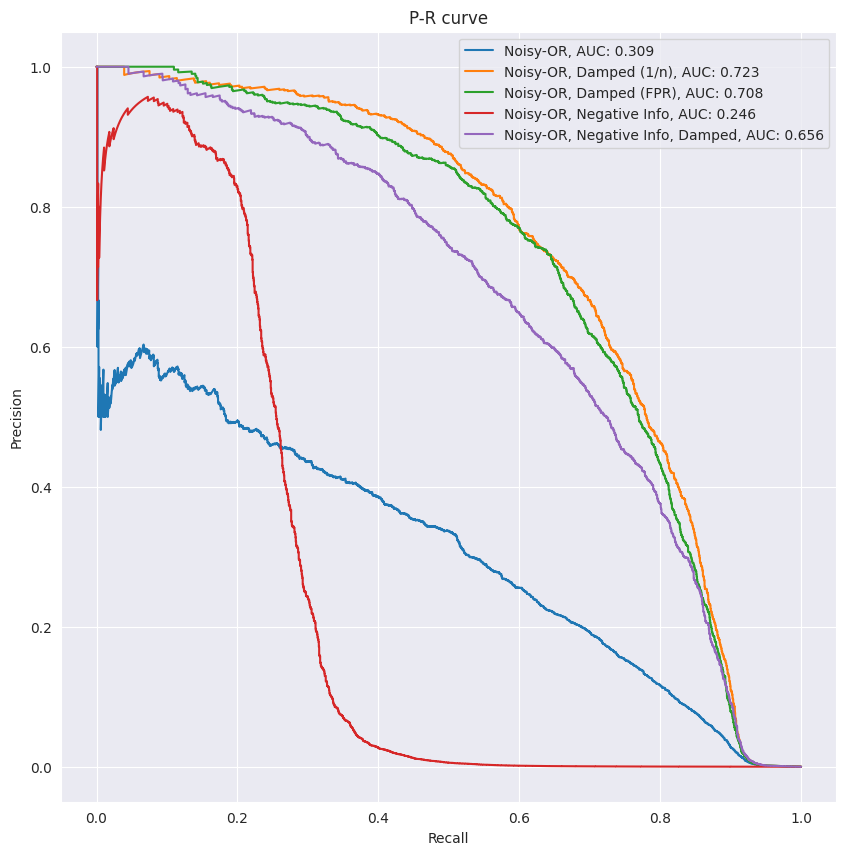

In [53]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_50_98_df[(~pca_50_98_df["drach"]) & (pca_50_98_df["count_dom"] >= 100) & (pca_50_98_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"] + selected_df["logsum_pca"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info, Damped, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


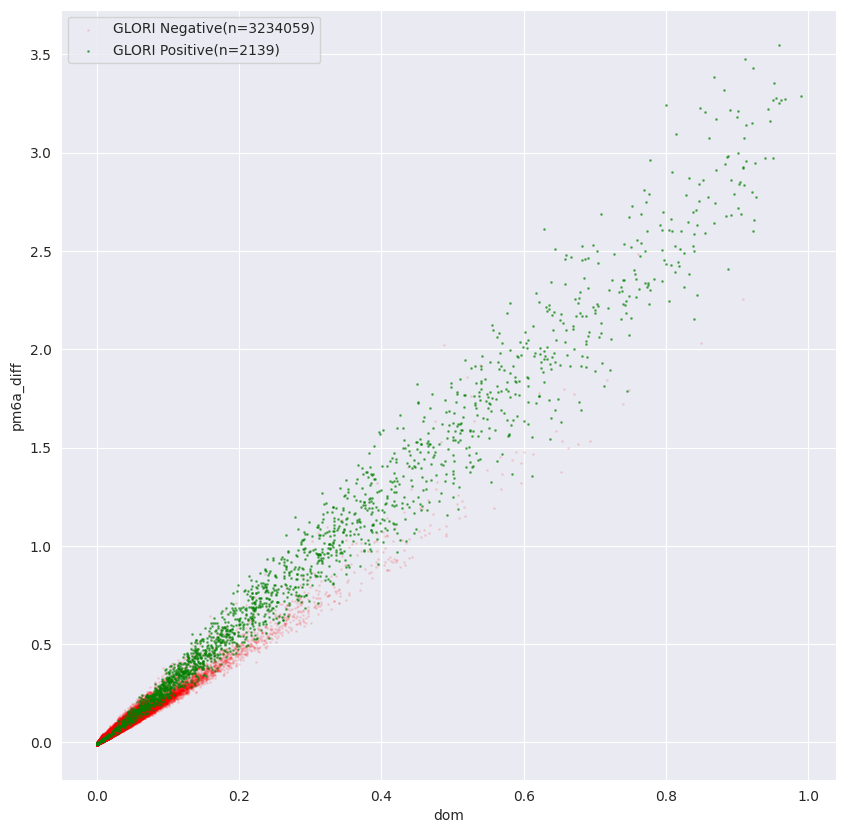

In [56]:
fpr = 0.0027
selected_df = pca_50_98_df[(~pca_50_98_df["drach"]) & (pca_50_98_df["count_dom"] >= 100) & (pca_50_98_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pm6a"]+selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pm6a"]+selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

In [57]:
pca_and_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_pca_and/pileup.npz"
with np.load(pca_and_df, allow_pickle=True) as data:
    pca_and_df = pd.DataFrame({key: data[key] for key in data.keys()})
pca_and_df = pca_and_df[pca_and_df["count_dom"] >= 20]
pca_and_df = pca_and_df.merge(label_df_filtered, on="label_id", how="inner")
print(pca_and_df)

                label_id      pm6a  count_pm6a       pca  count_pca  \
0         NM_000016:1000  0.000000           0  0.520655        258   
1         NM_000016:1008  0.000000           0  0.288685        257   
2         NM_000016:1009  0.000000           0  0.018568        260   
3         NM_000016:1010  0.000000           0  0.001203        263   
4         NM_000016:1014  0.000000           0  0.020705        258   
...                  ...       ...         ...       ...        ...   
10794116  NR_182669:3964  0.000000           0  0.234761         54   
10794117  NR_182669:3965  0.000000           0  0.177520         53   
10794118  NR_182669:3966  0.000000           0  0.183460         50   
10794119  NR_182669:3968  0.984304           1  0.001145         48   
10794120  NR_182669:3969  0.000000           0  0.087323         45   

          logsum_pca       dom  count_dom  count  logsum_pm6a  depth  label  \
0          -0.283450  0.000000        258    258     0.000000    268

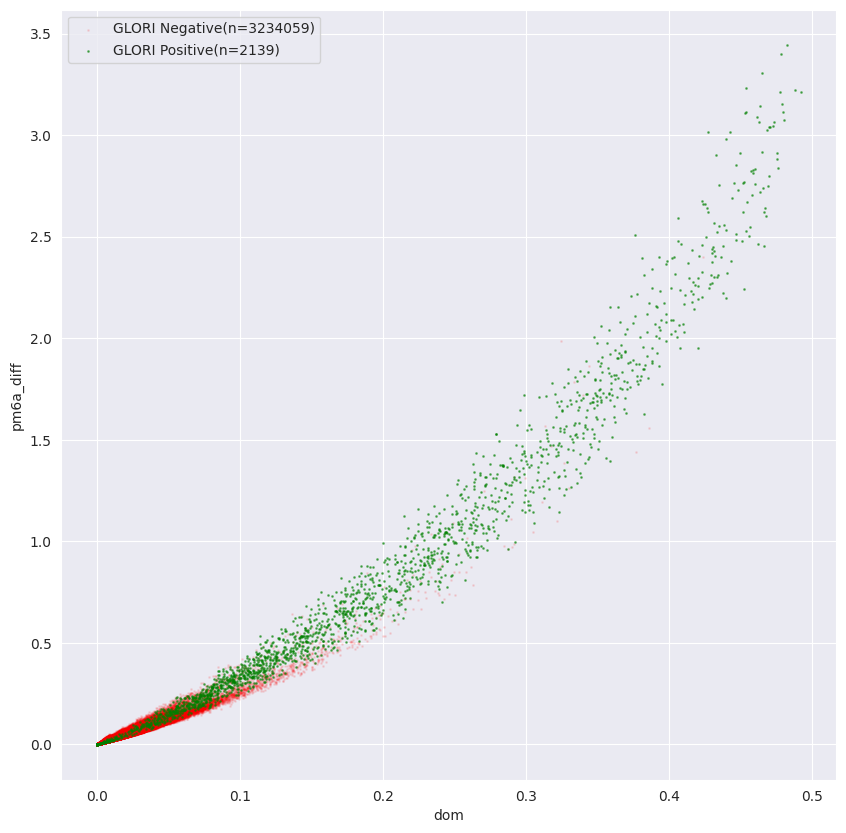

In [60]:
fpr = 0.0027
selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pca"])*fpr

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

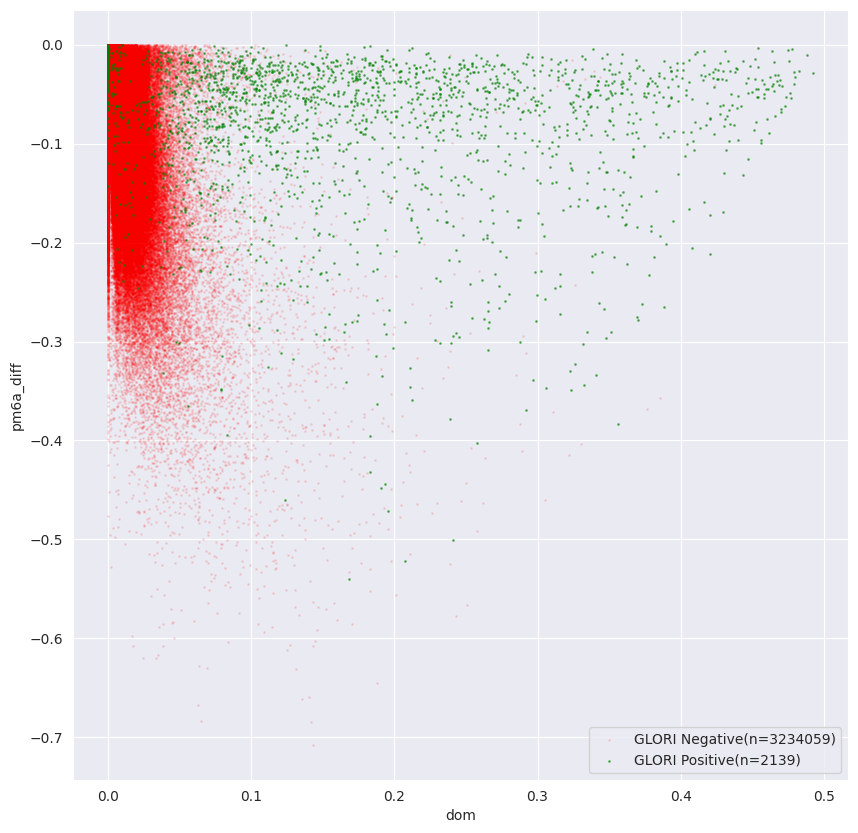

In [61]:
fpr = 0.0027
selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pca"]) + selected_df["logsum_pca"]/(selected_df["count_pca"])

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

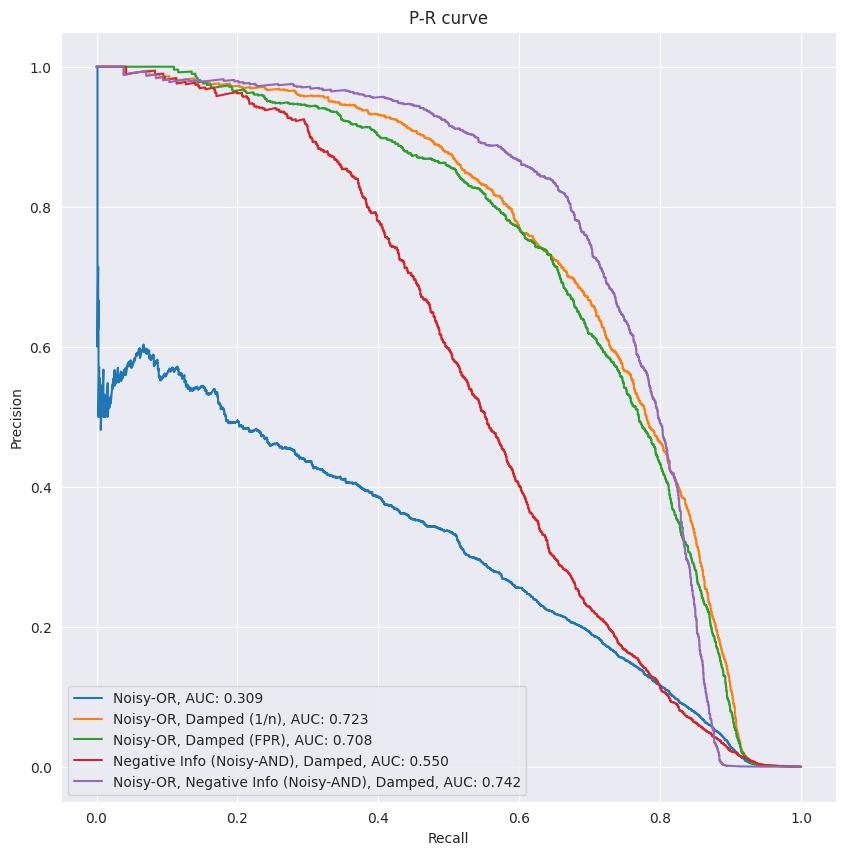

In [66]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pca_damp"] = selected_df["logsum_pca"] / selected_df["count"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/selected_df["count"] * 2 + selected_df["logsum_pca"]/selected_df["count"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pca_damp"]* -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Negative Info (Noisy-AND), Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info (Noisy-AND), Damped, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


In [64]:
print(selected_df)

                label_id  pm6a  count_pm6a           pca  count_pca  \
1         NM_000016:1008   0.0           0  2.886846e-01        257   
2         NM_000016:1009   0.0           0  1.856807e-02        260   
3         NM_000016:1010   0.0           0  1.203293e-03        263   
4         NM_000016:1014   0.0           0  2.070487e-02        258   
5         NM_000016:1020   0.0           0  5.473902e-02        262   
...                  ...   ...         ...           ...        ...   
10792427   NR_182661:967   0.0           0  1.161015e-05        112   
10792428   NR_182661:975   0.0           0  1.498260e-02        108   
10792429   NR_182661:985   0.0           0  1.334931e-05        107   
10792431   NR_182661:993   0.0           0  1.534189e-04        107   
10792432   NR_182661:999   0.0           0  8.022307e-08        106   

          logsum_pca       dom  count_dom  count  logsum_pm6a  depth  label  \
1          -0.539576  0.000000        256    257          0.0    268

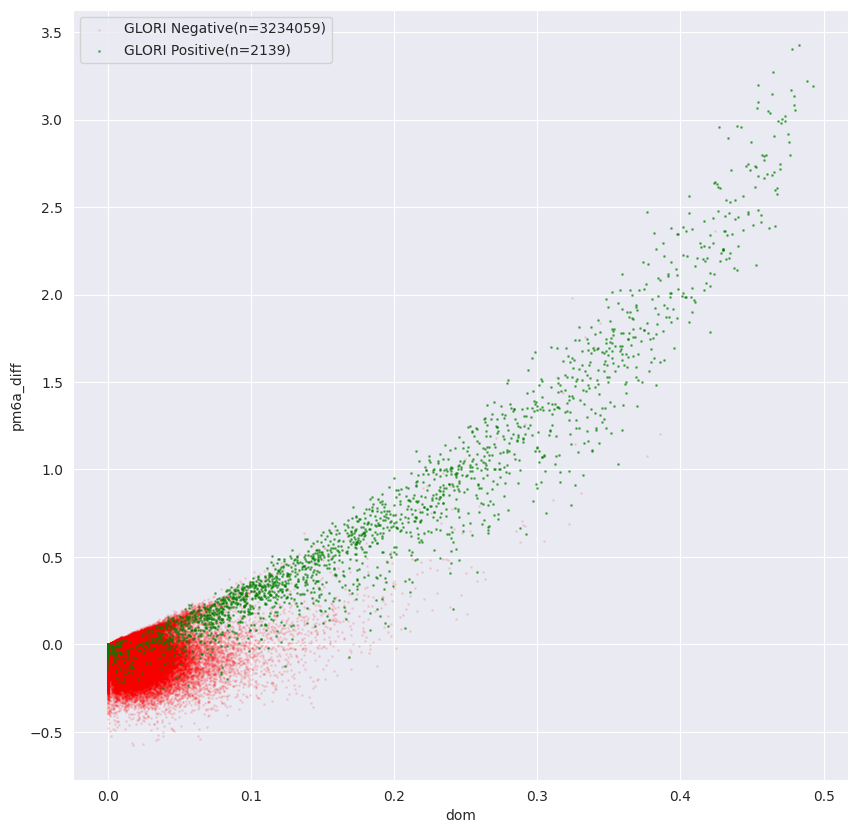

In [67]:
fpr = 0.0027
selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pca"]) * 2 + selected_df["logsum_pca"]/(selected_df["count_pca"])

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

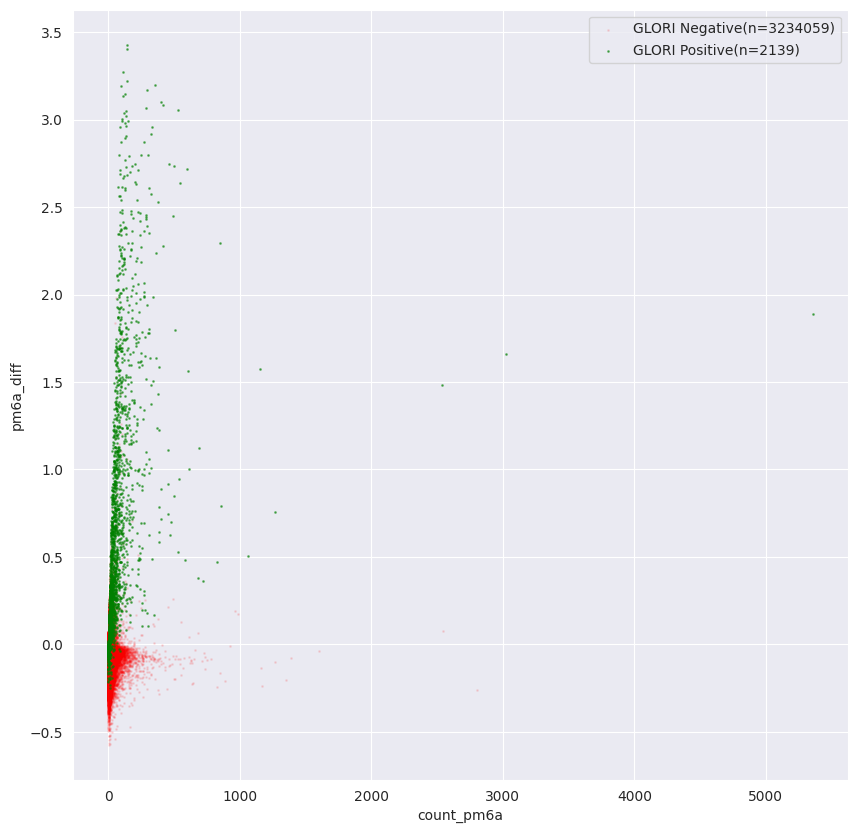

In [68]:
fpr = 0.0027
selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pca"]) * 2 + selected_df["logsum_pca"]/(selected_df["count_pca"])

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"], neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"], pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("count_pm6a")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

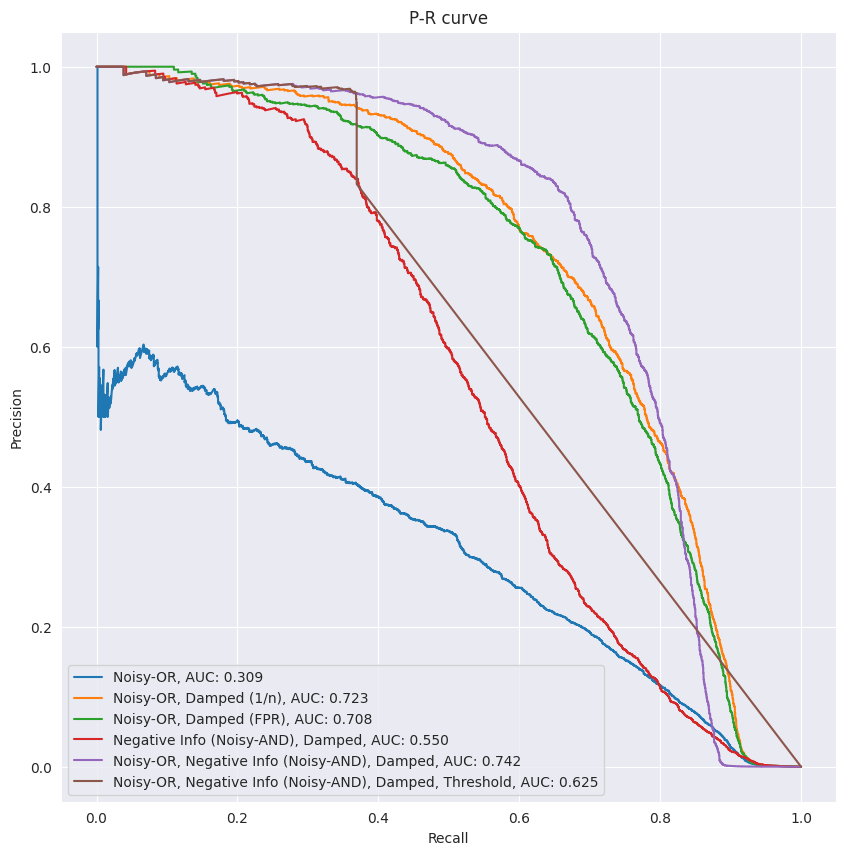

In [69]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pca_damp"] = selected_df["logsum_pca"] / selected_df["count"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/selected_df["count"] * 2 + selected_df["logsum_pca"]/selected_df["count"]
selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
selected_df["pm6a_diff_damp_thr"] = selected_df["pm6a_diff_damp"] * (selected_df["pm6a_diff_damp"] > selected_df["threshold"])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pca_damp"]* -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Negative Info (Noisy-AND), Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info (Noisy-AND), Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info (Noisy-AND), Damped, Threshold, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


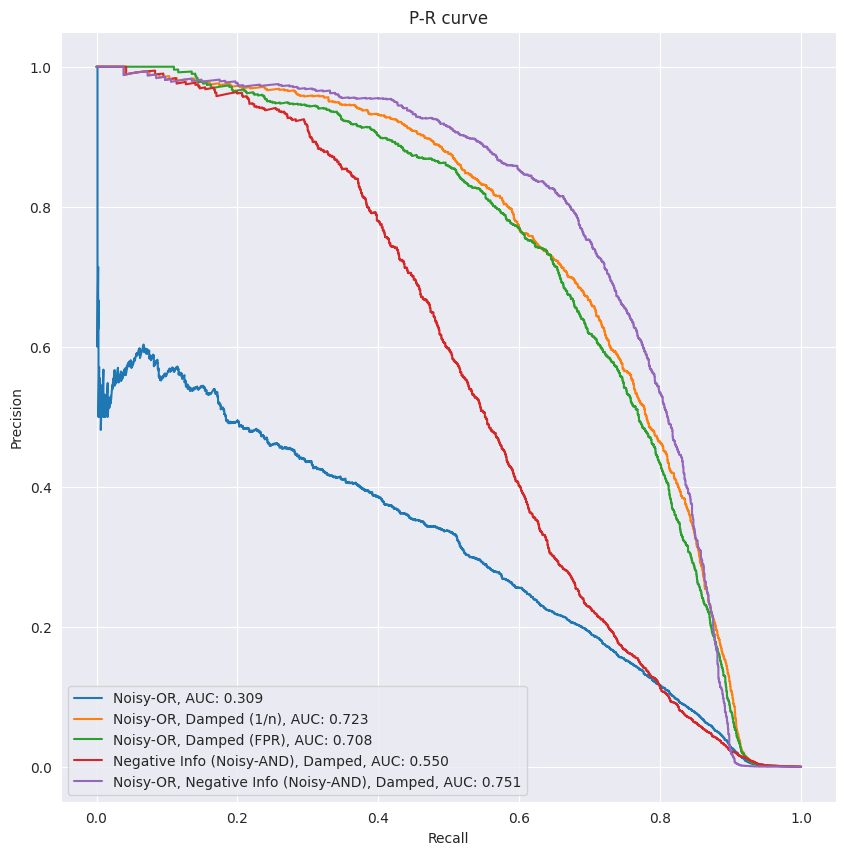

In [82]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pca_damp"] = selected_df["logsum_pca"] / selected_df["count"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/selected_df["count"] * -np.log10(fpr) + selected_df["logsum_pca"]/selected_df["count"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_fpr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (FPR), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pca_damp"]* -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Negative Info (Noisy-AND), Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info (Noisy-AND), Damped, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


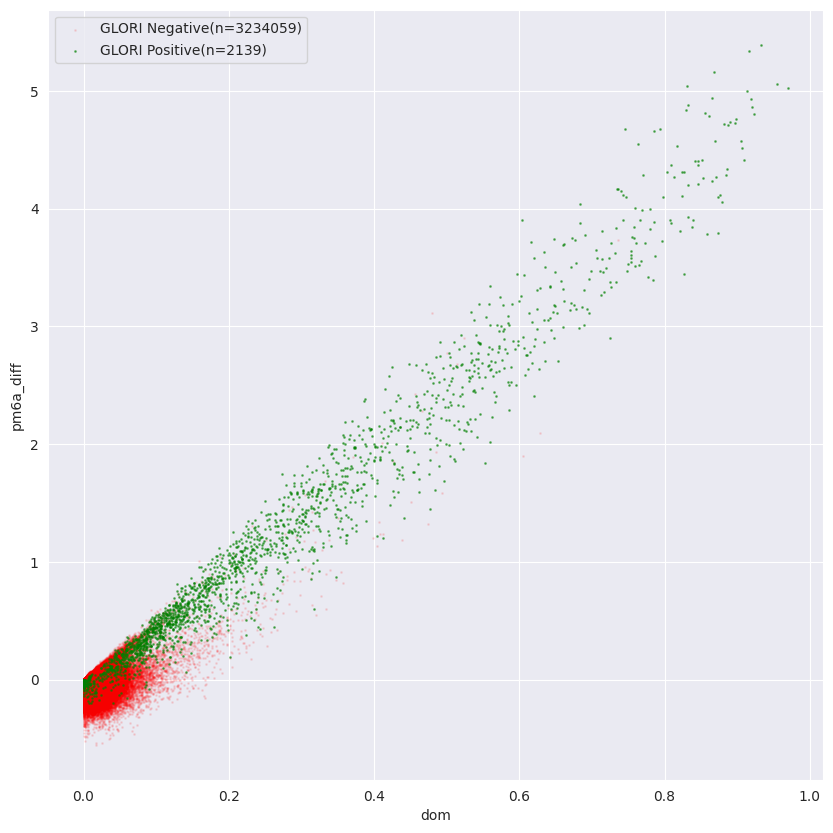

In [85]:
fpr = 0.0027
selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pca"]) * -np.log10(fpr) + selected_df["logsum_pca"]/(selected_df["count_pca"])

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/neg_df["count_pca"], neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/pos_df["count_pca"], pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

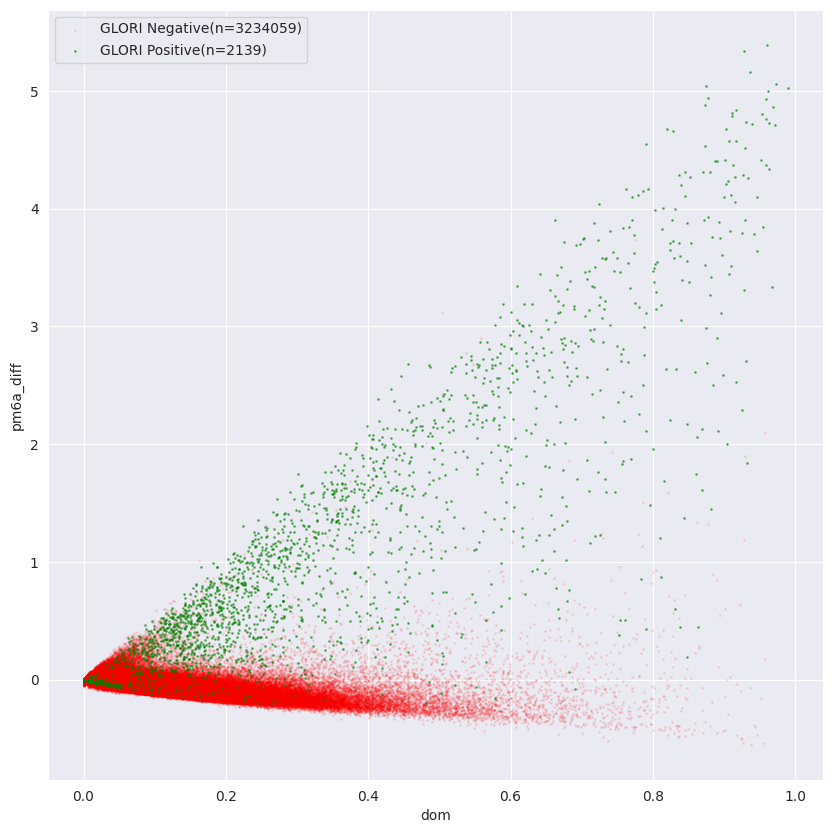

In [84]:
fpr = 0.0027
selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pca"]) * -np.log10(fpr) + selected_df["logsum_pca"]/(selected_df["count_pca"])

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["dom"], neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["dom"], pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

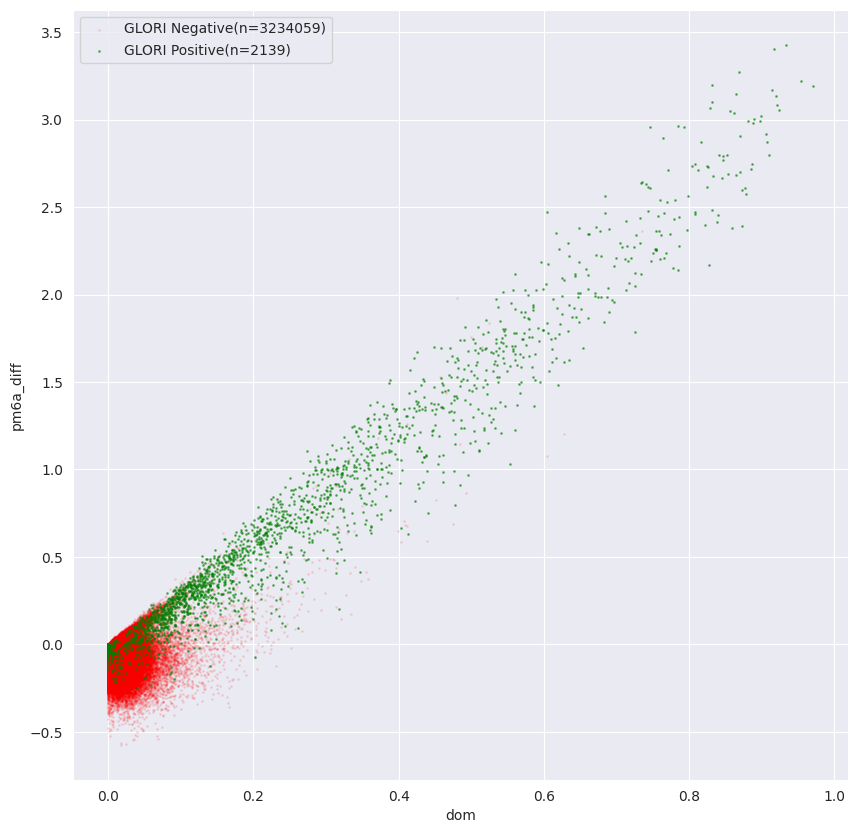

In [87]:
fpr = 0.0027
selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_diff"] = -selected_df["logsum_pm6a"]/(selected_df["count_pca"]) * 2 + selected_df["logsum_pca"]/(selected_df["count_pca"])

neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/neg_df["count_pca"], neg_df["pm6a_diff"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/pos_df["count_pca"], pos_df["pm6a_diff"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_diff")
plt.show()
plt.close() 

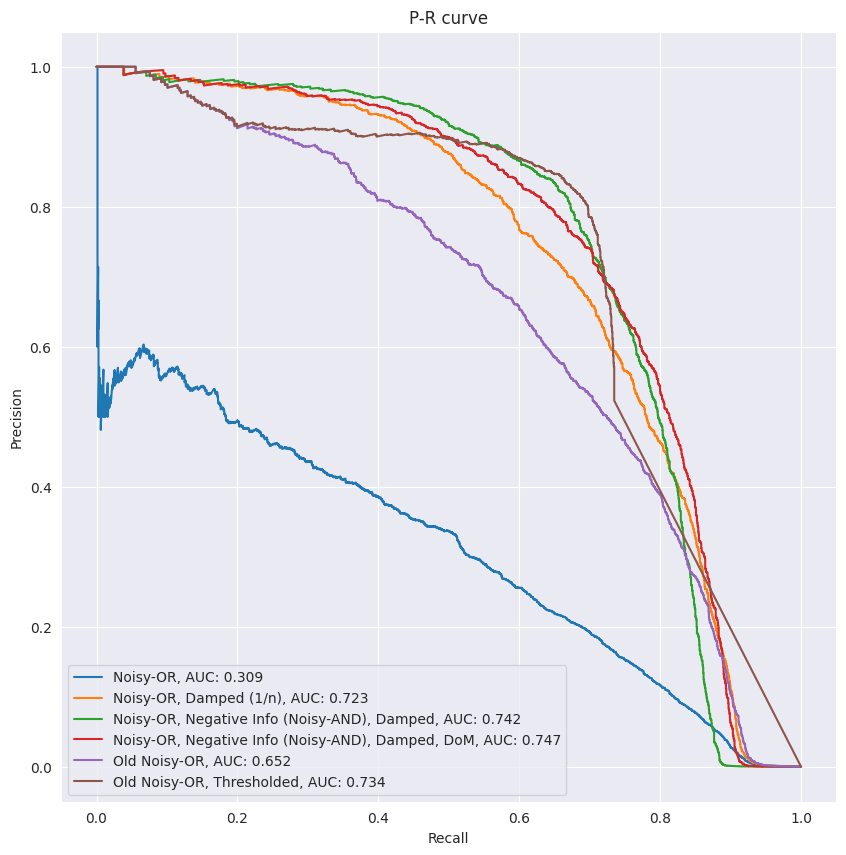

In [98]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pca_damp"] = selected_df["logsum_pca"] / selected_df["count"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/selected_df["count"] * 2 + selected_df["logsum_pca"]/selected_df["count"]

selected_df["pm6a_diff_damp_dom"] = -selected_df["logsum_pm6a"]/selected_df["count"] * 2 + selected_df["logsum_pca"]/selected_df["count"] - (selected_df["count_pm6a"]/selected_df["count_pca"]) * np.log10(fpr)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info (Noisy-AND), Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp_dom"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info (Noisy-AND), Damped, DoM, AUC: {auc_score:.3f}")


selected_df = cell_label_df[(~cell_label_df["drach"]) & (cell_label_df["count_pm6a"] >= 100) & (cell_label_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Old Noisy-OR, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Old Noisy-OR, Thresholded, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


In [97]:
pca_50_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_pca_and_50_50/pileup.npz"
with np.load(pca_50_df, allow_pickle=True) as data:
    pca_50_df = pd.DataFrame({key: data[key] for key in data.keys()})
pca_50_df = pca_50_df[pca_50_df["count_dom"] >= 20]
pca_50_df = pca_50_df.merge(label_df_filtered, on="label_id", how="inner")
print(pca_50_df)

                label_id      pm6a  count_pm6a       pca  count_pca  \
0         NM_000016:1000  0.000000           0  0.520655        258   
1         NM_000016:1008  0.578929           1  0.288685        257   
2         NM_000016:1009  0.869907           1  0.018568        260   
3         NM_000016:1010  0.984075           4  0.001203        263   
4         NM_000016:1014  0.503992           1  0.020705        258   
...                  ...       ...         ...       ...        ...   
10794116  NR_182669:3964  0.000000           0  0.234761         54   
10794117  NR_182669:3965  0.567227           1  0.177520         53   
10794118  NR_182669:3966  0.626337           1  0.183460         50   
10794119  NR_182669:3968  0.997981           2  0.001145         48   
10794120  NR_182669:3969  0.853994           2  0.087323         45   

          logsum_pca       dom  count_dom  count  logsum_pm6a  depth  label  \
0          -0.283450  0.000000        258    258     0.000000    268

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


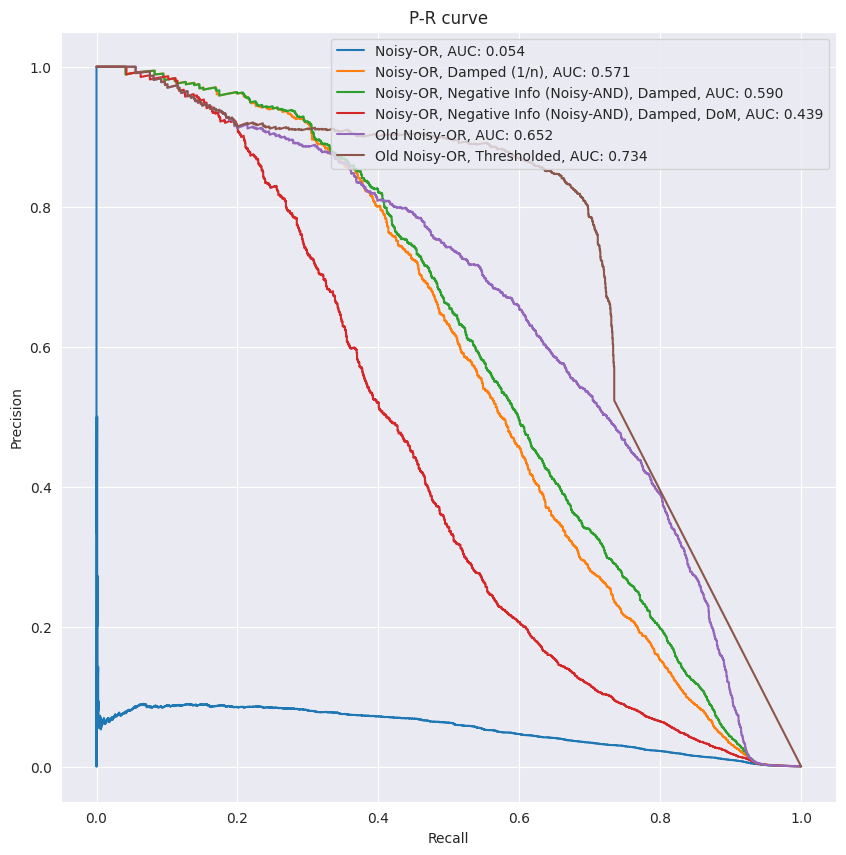

In [101]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.041

selected_df = pca_50_df[(~pca_50_df["drach"]) & (pca_50_df["count_dom"] >= 100) & (pca_50_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_damp_fpr"] = -(selected_df["logsum_pm6a"]/(1+fpr*selected_df["count"]))
selected_df["pm6a_damp_fpr_thr"] = selected_df["pm6a_damp_fpr"] * (selected_df["count"] < 2000)
selected_df["pca_damp"] = selected_df["logsum_pca"] / selected_df["count"]
selected_df["pm6a_diff_damp"] = -selected_df["logsum_pm6a"]/selected_df["count"] * 2 + selected_df["logsum_pca"]/selected_df["count"]
selected_df["pm6a_diff_damp_dom"] = -selected_df["logsum_pm6a"]/selected_df["count"] * 2 + selected_df["logsum_pca"]/selected_df["count"] - (selected_df["count_pm6a"]/selected_df["count_pca"]) * np.log10(fpr)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info (Noisy-AND), Damped, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff_damp_dom"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Negative Info (Noisy-AND), Damped, DoM, AUC: {auc_score:.3f}")


selected_df = cell_label_df[(~cell_label_df["drach"]) & (cell_label_df["count_pm6a"] >= 100) & (cell_label_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_thr"] = selected_df["pm6a"] * (selected_df["pm6a"] > selected_df["threshold"])


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Old Noisy-OR, AUC: {auc_score:.3f}")


precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_thr"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Old Noisy-OR, Thresholded, AUC: {auc_score:.3f}")


ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


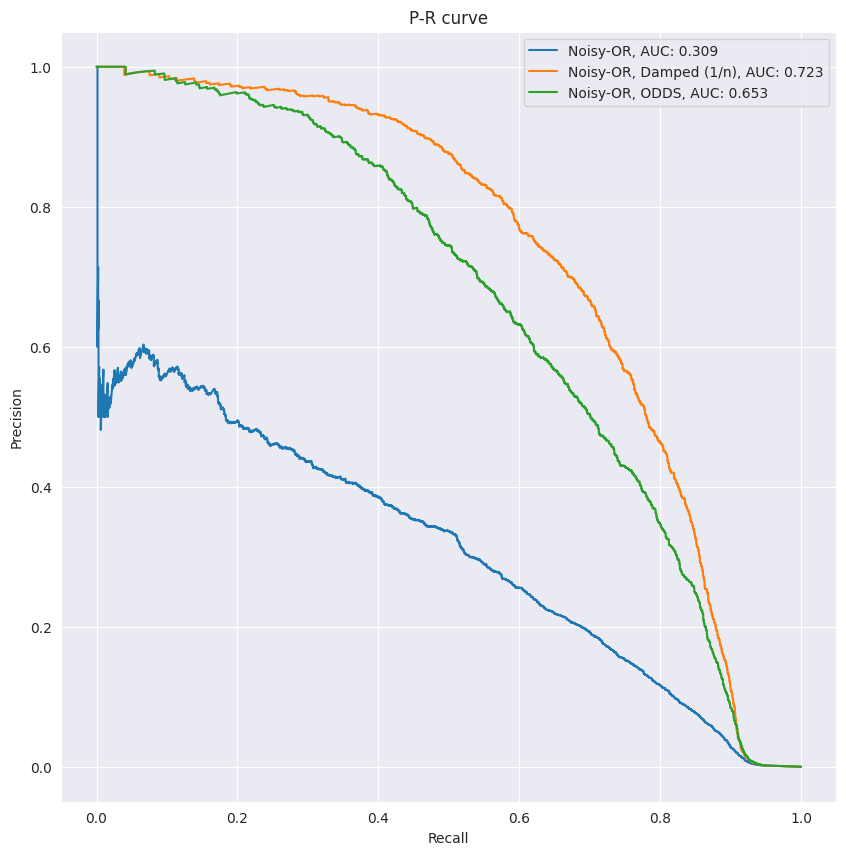

In [106]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None)) 
selected_df["pm6a_odds"] = (1- 10 ** (selected_df["logsum_pm6a"]/selected_df["count"])) / (10**(selected_df["logsum_pca"]/selected_df["count"]))

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["logsum_pm6a"] * -1)
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")
  
precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_odds"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, ODDS, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


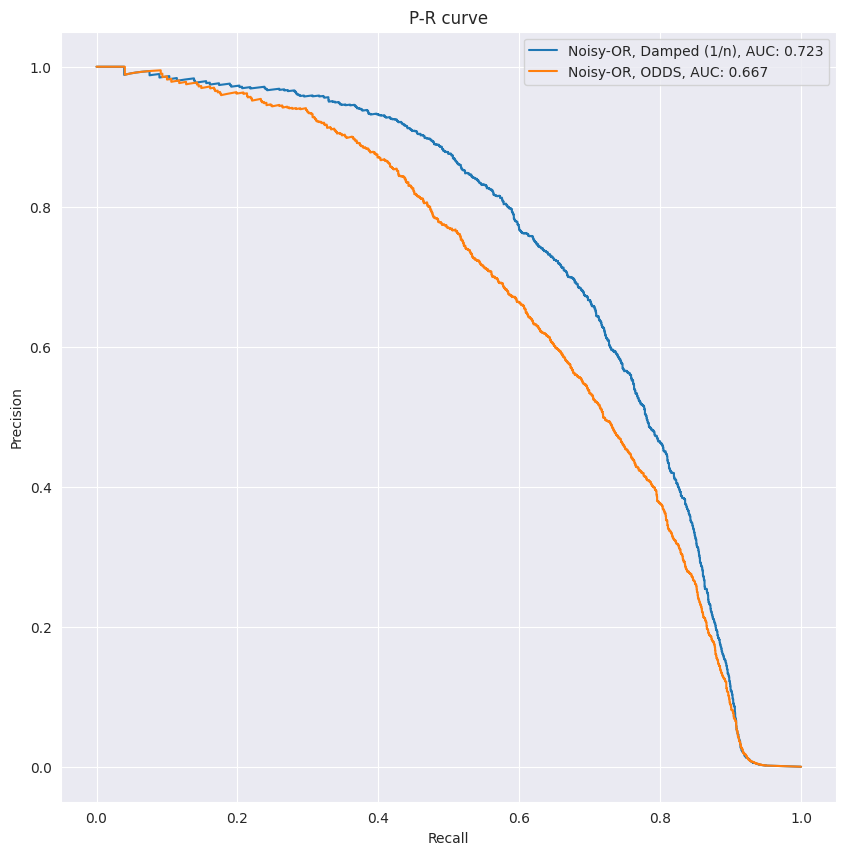

In [140]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_odds"] = (selected_df["count_pm6a"]/selected_df["count"]) / (1-(selected_df["count_pm6a"]/selected_df["count"])) * (1 - 10 ** (selected_df["logsum_pm6a"]/selected_df["count"])) / (10**(selected_df["logsum_pca"]/selected_df["count"]))

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_odds"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, ODDS, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


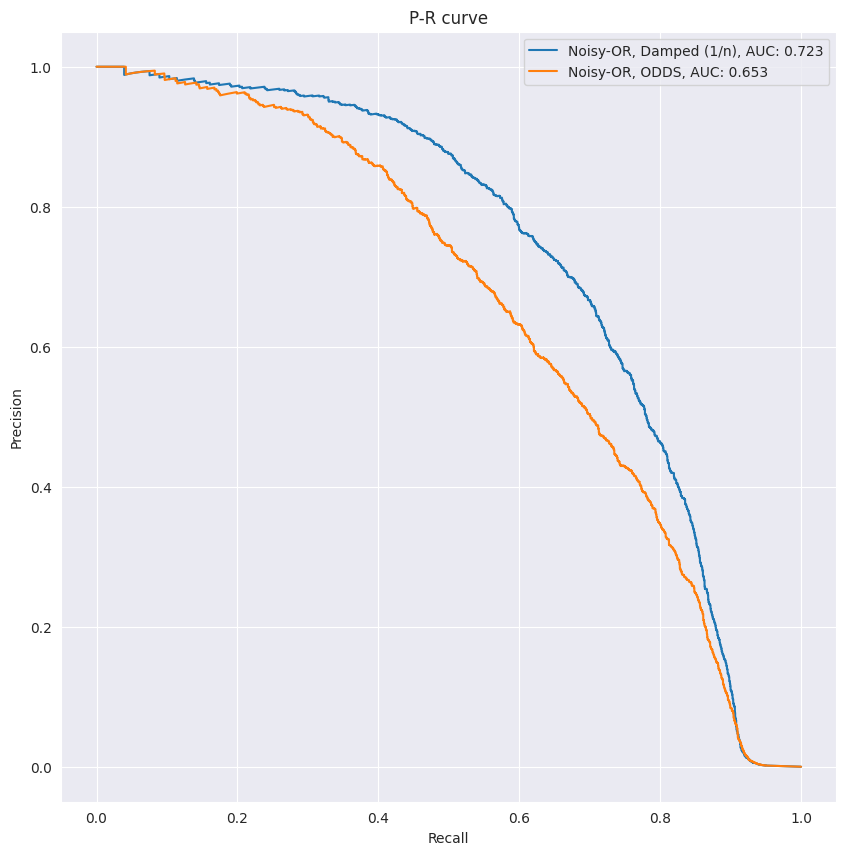

In [136]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_odds"] =  (1 - 10 ** (selected_df["logsum_pm6a"]/selected_df["count"])) / (10**(selected_df["logsum_pca"]/selected_df["count"]))

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_odds"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, ODDS, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


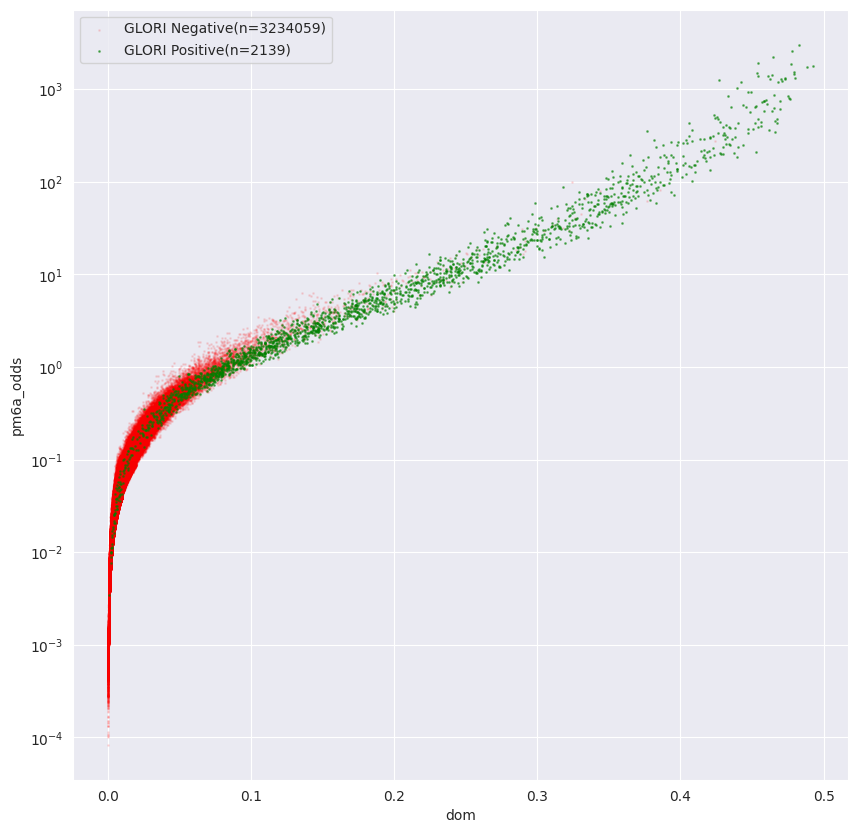

In [142]:
fpr = 0.0027
selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_odds"] =  (1 - 10 ** (selected_df["logsum_pm6a"]/selected_df["count"])) / (10**(selected_df["logsum_pca"]/selected_df["count"]))
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_odds")
ax.set_yscale("log")
plt.show()
plt.close() 

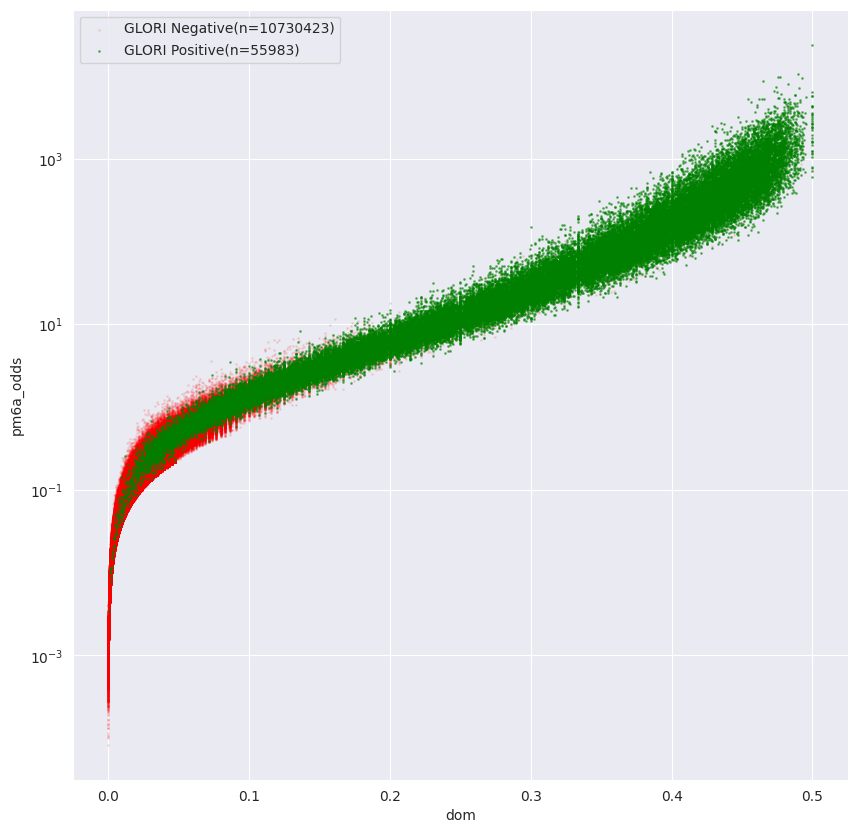

In [148]:
fpr = 0.0027
selected_df = pca_and_df[pca_and_df["label"] >= 0]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_odds"] =  (1 - 10 ** (selected_df["logsum_pm6a"]/selected_df["count"])) / (10**(selected_df["logsum_pca"]/selected_df["count"]))
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_odds")
ax.set_yscale("log")
plt.show()
plt.close()

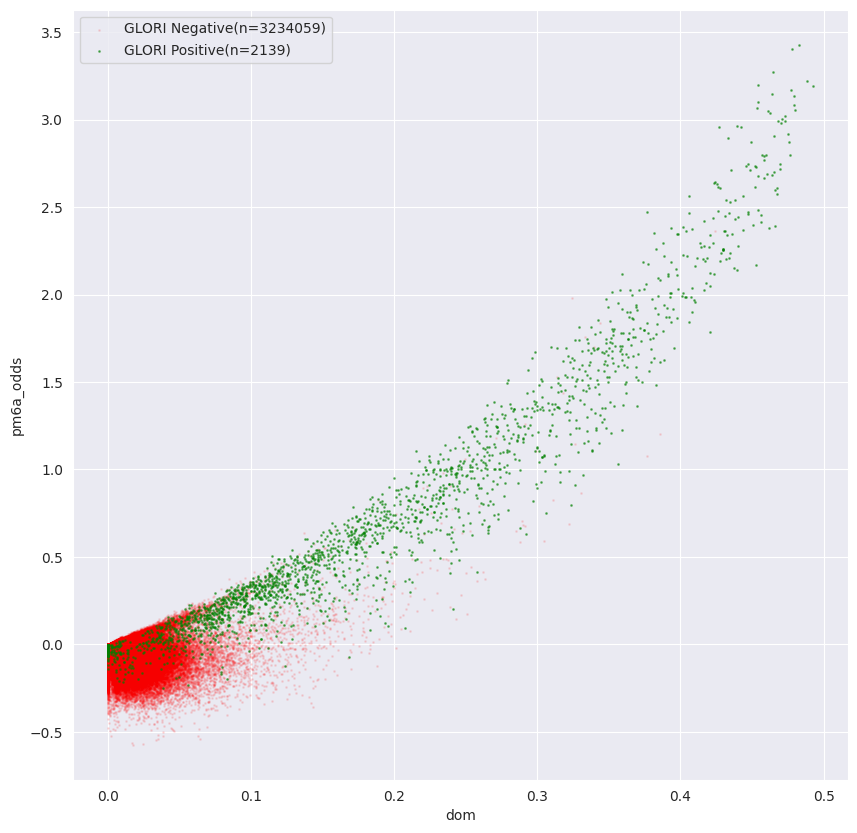

In [145]:
fpr = 0.0027
selected_df = pca_and_df[(~pca_and_df["drach"]) & (pca_and_df["count_dom"] >= 100) & (pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_odds"] =  - (2 * selected_df["logsum_pm6a"]/selected_df["count"]) + (selected_df["logsum_pca"]/selected_df["count"])
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_odds")
plt.show()
plt.close() 

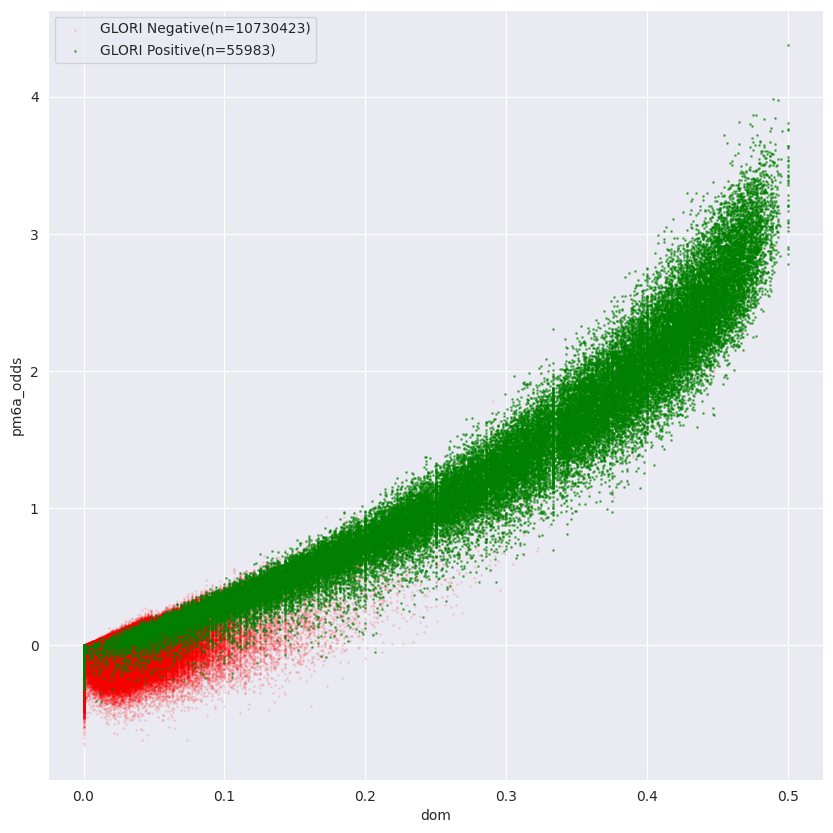

In [151]:
fpr = 0.0027
selected_df = pca_and_df[(pca_and_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_odds"] =  - (2 * selected_df["logsum_pm6a"]/selected_df["count"]) + (selected_df["logsum_pca"]/selected_df["count"])
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/(neg_df["count_pm6a"]+neg_df["count_pca"]), neg_df["pm6a_odds"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/(pos_df["count_pm6a"]+pos_df["count_pca"]), pos_df["pm6a_odds"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("pm6a_odds")
plt.show()
plt.close()

In [147]:
logsump_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v4-20240905-092858-10-177000-token_normalise_dwell_bq_npz_allmotif_pileup_logsump/pileup.npz"
with np.load(logsump_df, allow_pickle=True) as data:
    logsump_df = pd.DataFrame({key: data[key] for key in data.keys()})
logsump_df = logsump_df[logsump_df["count_dom"] >= 20]
logsump_df = logsump_df.merge(label_df_filtered, on="label_id", how="inner")
print(logsump_df)

                label_id      pm6a  count_pm6a       pca  count_pca  \
0         NM_000016:1000  0.000000           0  0.520655        258   
1         NM_000016:1008  0.000000           0  0.288685        257   
2         NM_000016:1009  0.000000           0  0.018568        260   
3         NM_000016:1010  0.000000           0  0.001203        263   
4         NM_000016:1014  0.000000           0  0.020705        258   
...                  ...       ...         ...       ...        ...   
10794116  NR_182669:3964  0.000000           0  0.234761         54   
10794117  NR_182669:3965  0.000000           0  0.177520         53   
10794118  NR_182669:3966  0.000000           0  0.183460         50   
10794119  NR_182669:3968  0.984304           1  0.001145         48   
10794120  NR_182669:3969  0.000000           0  0.087323         45   

          logsum_pca    logsum_p       dom  count_dom  count  logsum_pm6a  \
0          -0.283450 -958.656189  0.000000        258    258     0.000

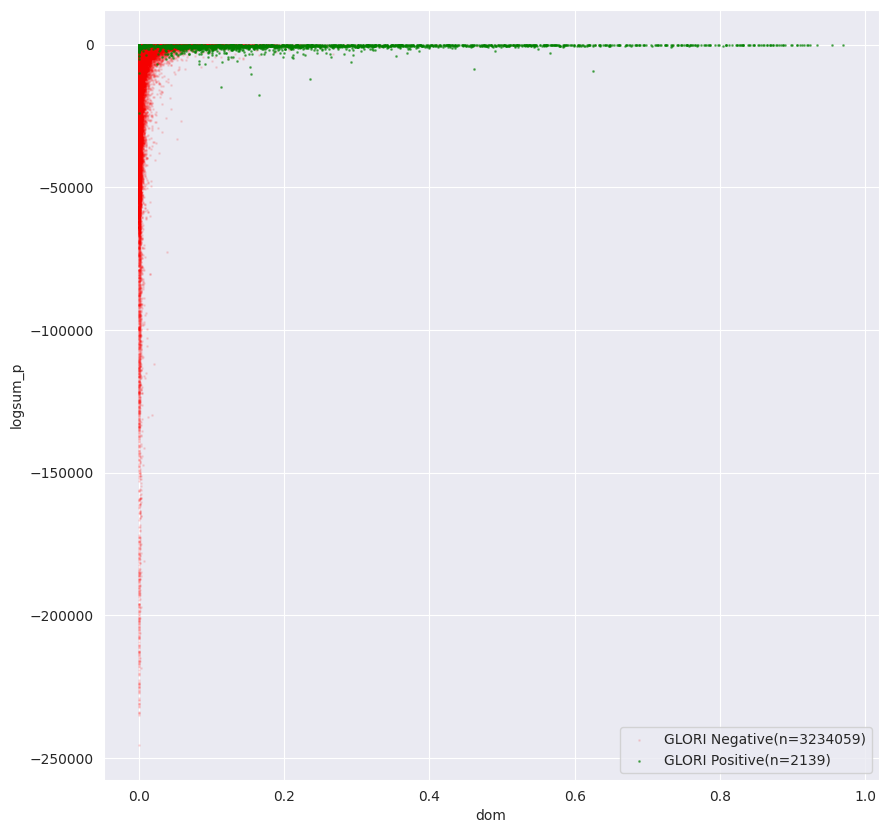

In [153]:
fpr = 0.0027
selected_df = logsump_df[(~logsump_df["drach"]) & (logsump_df["count_dom"] >= 100) & (logsump_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)] 
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/neg_df["count_pca"], neg_df["logsum_p"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/pos_df["count_pca"], pos_df["logsum_p"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("logsum_p")
plt.show()
plt.close() 

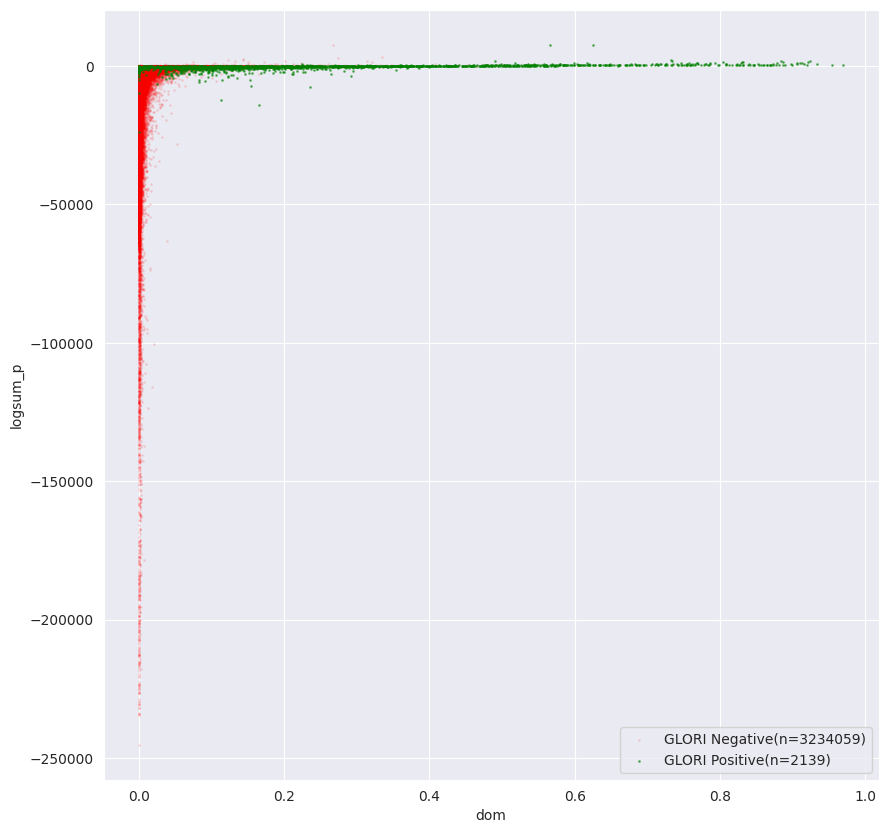

In [155]:
fpr = 0.0027
selected_df = logsump_df[(~logsump_df["drach"]) & (logsump_df["count_dom"] >= 100) & (logsump_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
neg_df = selected_df[selected_df["dom_label"] == 0]
pos_df = selected_df[selected_df["dom_label"] > 0]

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(neg_df["count_pm6a"]/neg_df["count_pca"], neg_df["logsum_p"] - neg_df["logsum_pca"], alpha=0.1, s = 1, color="red", label=f"GLORI Negative(n={len(neg_df)})")
ax.scatter(pos_df["count_pm6a"]/pos_df["count_pca"], pos_df["logsum_p"] - pos_df["logsum_pca"], alpha=0.5, s = 1, color="green", label=f"GLORI Positive(n={len(pos_df)})")
ax.legend()
ax.set_xlabel("dom")
ax.set_ylabel("logsum_p")
plt.show()
plt.close()

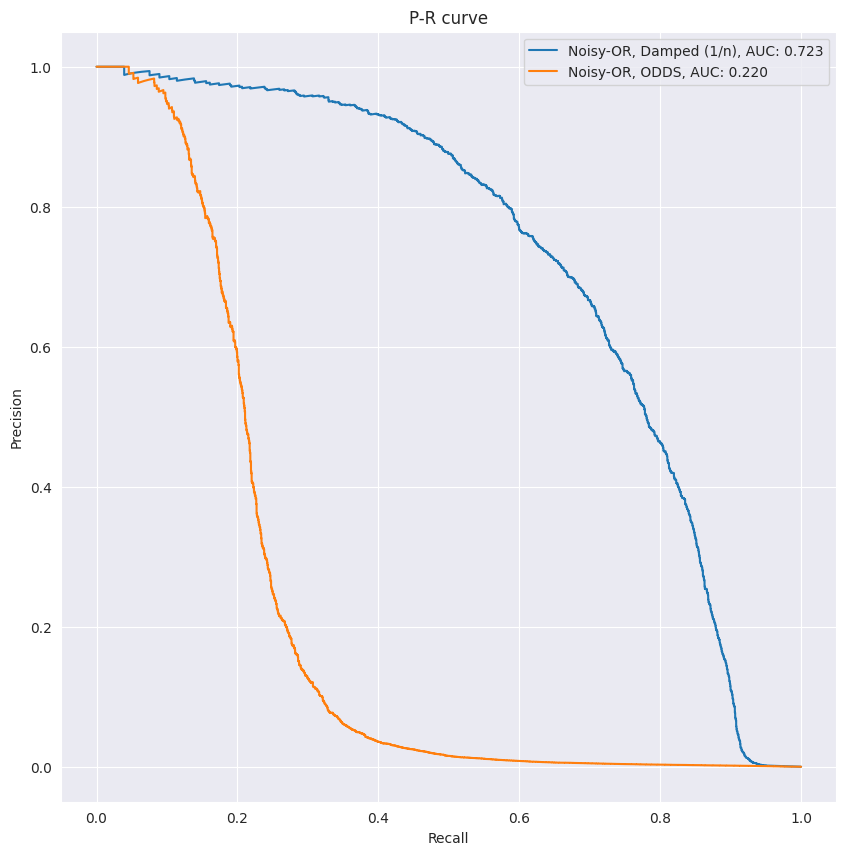

In [157]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = logsump_df[(~logsump_df["drach"]) & (logsump_df["count_dom"] >= 100) & (logsump_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_diff"] = (selected_df["logsum_p"] - selected_df["logsum_pca"])/selected_df["count"]

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, ODDS, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


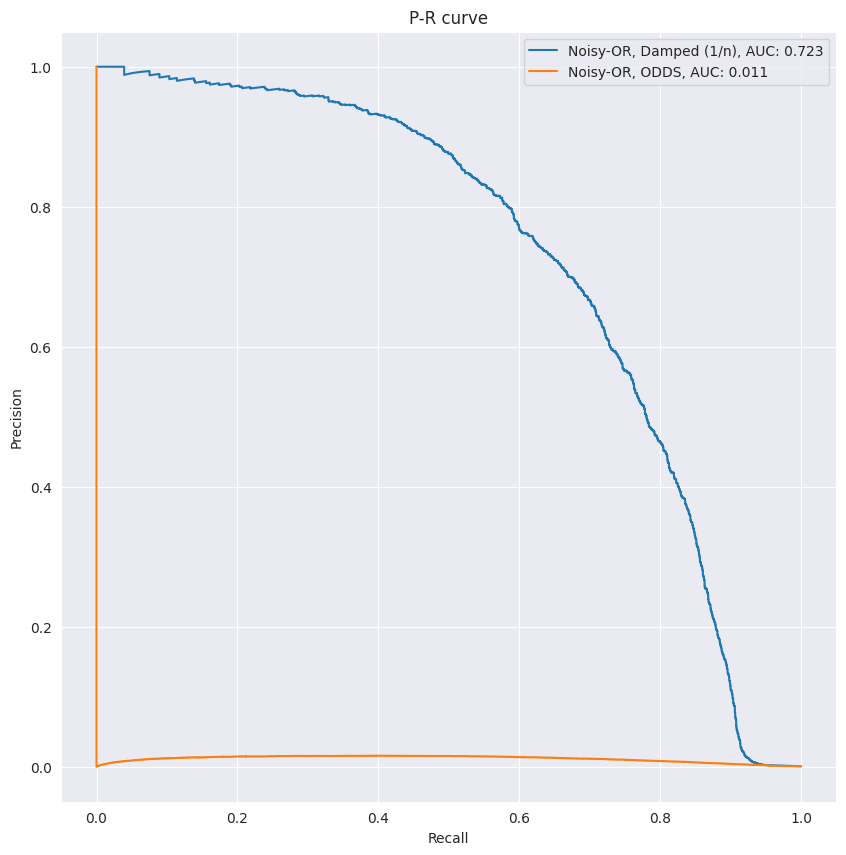

In [170]:
from sklearn.metrics import precision_recall_curve, auc

fpr = 0.0027

selected_df = logsump_df[(~logsump_df["drach"]) & (logsump_df["count_dom"] >= 100) & (logsump_df["label"] >= 0)]
selected_df = selected_df[(selected_df["label"] == 0)|(selected_df["dom_label"] > 0.1)]
selected_df["pm6a_damp_abs"] = -(selected_df["logsum_pm6a"]/np.clip(selected_df["count"],1,None))
selected_df["pm6a_diff"] = (selected_df["logsum_pca"]  - selected_df["logsum_pm6a"]) / (selected_df["count"] - selected_df["count_pm6a"]) - selected_df["logsum_pm6a"] / np.clip(selected_df["count_pm6a"],1,None)

selected_df["threshold"] = 1-(1-0.98)**selected_df["dom"]
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_damp_abs"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, Damped (1/n), AUC: {auc_score:.3f}")

precision, recall, _ = precision_recall_curve(selected_df["label"], selected_df["pm6a_diff"])
auc_score = auc(recall, precision)
ax.plot(recall, precision, label=f"Noisy-OR, ODDS, AUC: {auc_score:.3f}")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("P-R curve")
ax.legend()
plt.show()
plt.close()


In [ ]:
print(selected_df["pm6a_diff"])